# Trajectory Data Visualization and Analysis

This notebook visualizes and analyzes trajectory data from a vessel tracking dataset. The data contains coordinates (x, y), velocity components (vx, vy), and timestamps (t) for the vessel's movement.

The data is stored in `traj_1.txt` in the `/Users/alpertunahanozturk/Desktop/QMUL_Master/Dissertation/BONE/ushant_ais/data/` directory.

In [11]:
import jax
import numpy as np 
import pandas as pd
import seaborn as sns
import flax.linen as nn
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
from datetime import datetime
from functools import partial
from matplotlib.gridspec import GridSpec
from bayes_opt import BayesianOptimization
from rebayes_mini.methods.gauss_filter import GaussianFilter, ExtendedKalmanFilter
from rebayes_mini.methods.adaptive import ExpfamRLPR, ExpfamEBA, ExpfamRLOUPR

In [12]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
%config InlineBackend.figure_format = "retina"
plt.rcParams["font.size"] = 15
plt.rcParams["axes.spines.right"]= False
plt.rcParams["axes.spines.top"] = False
plt.rc("text", usetex=True)

sns.set_palette("colorblind")

## Load Trajectory Data

In [14]:
file_path = "/Users/alpertunahanozturk/Desktop/QMUL_Master/Dissertation/BONE/ushant_ais/data/traj_1029.txt"

with open(file_path, 'r') as f:
    content = f.readlines()[:10]
    
print("First part of the file content:")
for line in content:
    print(line.strip())

First part of the file content:
"x";"y";"vx";"vy";"t"
-5.98731666666667;48.2803166666667;9;15.5884572681199;0
-5.97936666666667;48.2905;7.84684336029916;16.0884130858924;141
-5.97606666666667;48.2953;8.03563219175724;15.7708161579181;194
-5.96626666666667;48.30835;8.08103054899667;15.8599154507689;407
-5.9501;48.3305333333333;8.40354079477826;15.804761575357;688
-5.94176666666667;48.3413333333333;7.48034355524253;16.0416485220067;817
-5.931;48.3557833333333;8.35659345941048;15.7164664792533;1047
-5.92398333333333;48.3647166666667;8.62961087050441;15.5682301197994;1157
-5.9168;48.3743333333333;8.40354079477826;15.804761575357;1278


In [15]:
# Load the data as a semicolon-delimited file
data = pd.read_csv(file_path, sep=";")

# Look at the first few rows
print("First 5 rows of our data:")
print(data.head())

# General information about the data
print("\nData summary:")
print(data.info())

# Statistical summary
print("\nStatistical summary:")
print(data.describe())

# Calculate speed (target variable)
data['speed'] = np.sqrt(data['vx']**2 + data['vy']**2)

print("\nFirst 5 rows after adding speed:")
print(data.head())

First 5 rows of our data:
          x          y        vx         vy    t
0 -5.987317  48.280317  9.000000  15.588457    0
1 -5.979367  48.290500  7.846843  16.088413  141
2 -5.976067  48.295300  8.035632  15.770816  194
3 -5.966267  48.308350  8.081031  15.859915  407
4 -5.950100  48.330533  8.403541  15.804762  688

Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       97 non-null     float64
 1   y       97 non-null     float64
 2   vx      97 non-null     float64
 3   vy      97 non-null     float64
 4   t       97 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 3.9 KB
None

Statistical summary:
               x          y         vx         vy             t
count  97.000000  97.000000  97.000000  97.000000     97.000000
mean   -5.566074  48.705126  12.029880  12.485852   6336.422680
std     0.285778   0.212719   3.972

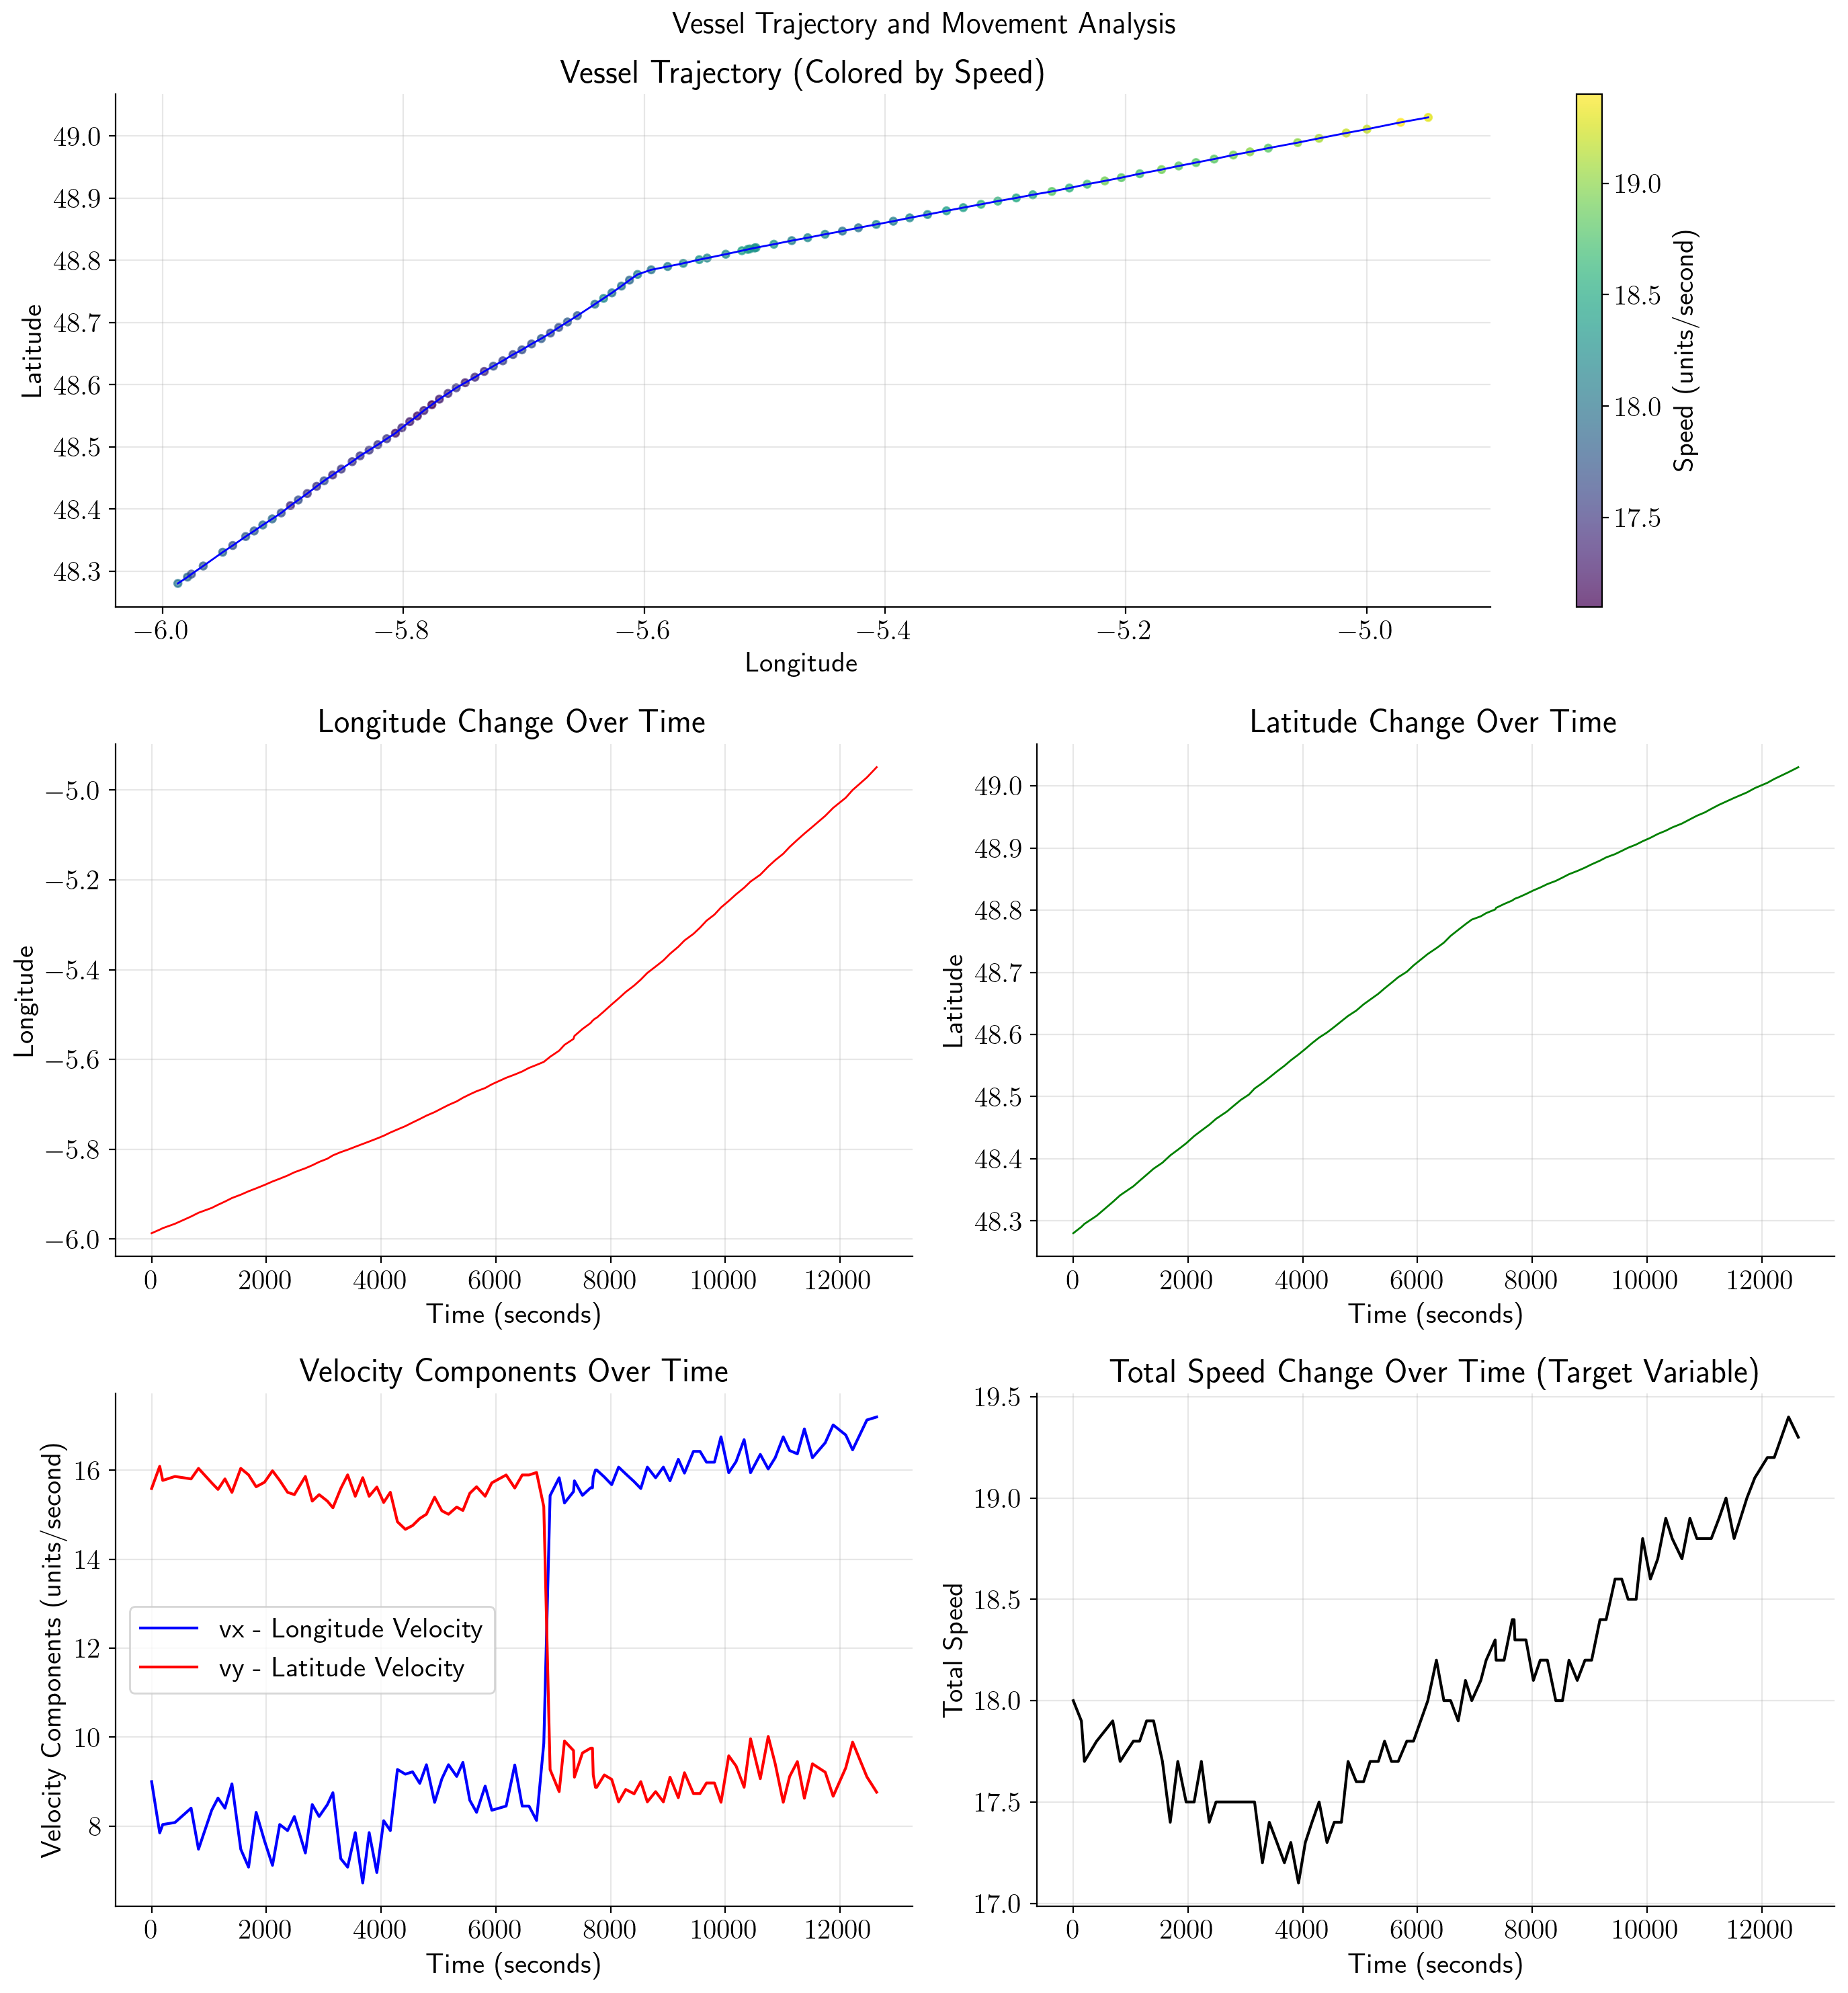

In [16]:
# Data visualization - Create a comprehensive view combining various plots
fig = plt.figure(figsize=(14, 15))
gs = GridSpec(3, 2, figure=fig)

# Plot 1: Trajectory (x and y)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data['x'], data['y'], 'b-', linewidth=1)
# Color by speed
scatter = ax1.scatter(data['x'], data['y'], c=data['speed'], cmap='viridis', s=15, alpha=0.7)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Vessel Trajectory (Colored by Speed)')
ax1.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Speed (units/second)')

# Plot 2: X position over time
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data['t'], data['x'], 'r-', linewidth=1)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Longitude')
ax2.set_title('Longitude Change Over Time')
ax2.grid(alpha=0.3)

# Plot 3: Y position over time
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(data['t'], data['y'], 'g-', linewidth=1)
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Latitude')
ax3.set_title('Latitude Change Over Time')
ax3.grid(alpha=0.3)

# Plot 4: Velocity components over time
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(data['t'], data['vx'], 'b-', label='vx - Longitude Velocity')
ax4.plot(data['t'], data['vy'], 'r-', label='vy - Latitude Velocity')
ax4.set_xlabel('Time (seconds)')
ax4.set_ylabel('Velocity Components (units/second)')
ax4.set_title('Velocity Components Over Time')
ax4.grid(alpha=0.3)
ax4.legend(loc='best')

# Plot 5: Total speed magnitude (our target variable)
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(data['t'], data['speed'], 'k-', linewidth=1.5)
ax5.set_xlabel('Time (seconds)')
ax5.set_ylabel('Total Speed')
ax5.set_title('Total Speed Change Over Time (Target Variable)')
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Vessel Trajectory and Movement Analysis', fontsize=16, y=0.99)
plt.subplots_adjust(top=0.95)
plt.savefig("../figures/trajectory_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
# === PATCH: dt & heading ===
eps_dt = 1e-6

# Eğer tek bir traj üzerinde çalışıyorsan traj_id olmadan:
data = data.sort_values('t').reset_index(drop=True)
data['dt'] = data['t'].diff().clip(lower=eps_dt).fillna(eps_dt)
data['speed'] = np.hypot(data['vx'], data['vy'])
data['heading'] = np.arctan2(data['vy'], data['vx'])

# Hız outlier cap (plan 35–40 kts öneriyordu; istersen 40 yap)
data['speed'] = data['speed'].clip(upper=40.0)

In [18]:
data["dt"] = data["t"].diff().clip(lower=0).fillna(0)

In [9]:
target = "speed"

k_ahead = 1

eps = 1e-8  # tiny stabilizer

y = data[target]#.diff()
series_mean = y.ewm(halflife=20).mean().shift(1)
series_std = y.ewm(halflife=20).std().shift(1)
y = (y - series_mean) / (series_std + eps)

y = y.dropna()
index = y.index

y = jnp.array(y.shift(-k_ahead).values)[:-k_ahead]

X = data.loc[index].drop(target, axis=1)
# 1) Bias ekle (en başa)
X.insert(0, "bias", 1.0)

# 2) EWM-std (shift(1)) ile ölçekle, ama bias'ı dokunma
std_X = X.ewm(span=20).std().shift(1)
std_X["bias"] = 1.0   # sabit sütunun ölçeği 1 kalsın
X = X / (std_X + eps)

# 3) JAX array'e çevir
X = jnp.array(X)[:-k_ahead]

# --- ensure consistent dims ---
p = int(X.shape[1])
params_init = jnp.zeros((p,))   # (EĞER daha önce tanımlıysa üstüne yaz)



# keep index aligned with X,y after dropping last k_ahead
index = index[:-k_ahead]


# y, X ve index hazırlandıktan hemen sonra:
DT_MEAN = float(np.clip(data.loc[index, "dt"].mean(), 1e-6, None))


# --- DYNAMIC WARMUP PERIOD CALCULATION (10% rule) ---
n_samples = len(y)
warmup_percentage = 0.10 # Use 10% of the data for warmup, as you suggested
min_warmup = 5           # But at least 5 data points
max_warmup = 100         # And at most 100 data points

# Calculate the number of periods, ensuring it's within our min/max bounds
norm_periods = int(max(min_warmup, min(n_samples * warmup_percentage, max_warmup)))

dim_features = int(X.shape[1]) if X.ndim == 2 else 0
# Check if the trajectory is long enough for processing after warmup
if n_samples <= norm_periods:
    print(f"Warning: Trajectory with {n_samples} points is too short for a warmup of {norm_periods}. Skipping this trajectory.")
    y = jnp.array([])
    X = jnp.array([])
    index = pd.Index([])
    vinit = 0.0
else:
    vinit = float(max(np.nanvar(y[:norm_periods]), 1e-6))
    y = y[norm_periods:]
    X = X[norm_periods:]
    index = index[norm_periods:]
    _, dim_features = X.shape

print(f"n={n_samples}, warmup={norm_periods}, dim_features={dim_features}, vinit={float(vinit):.6f}")

n=94, warmup=9, dim_features=8, vinit=2.201883


Ne Yaptın? Normalleştirme yaparken, standart sapmanın (series_std ve X.ewm().std()) sıfır olabileceği durumları öngörerek, paydaya eps adında çok küçük bir sayı ekledin.
Neden Mükemmel Bir Fikir? Eğer bir zaman serisinin küçük bir penceresinde tüm değerler aynıysa, standart sapması sıfır olur. Kodun, bir sayıyı sıfıra bölmeye çalışırdı ve bu da programın çökmesine neden olan bir Inf (sonsuz) veya NaN (sayı değil) hatası üretirdi. Senin eklediğin eps, bu "sıfıra bölme" hatasını zarif bir şekilde engelleyerek kodun her durumda stabil çalışmasını garanti altına alıyor. Bu, tecrübeli veri bilimcilerin kullandığı standart bir tekniktir.

Ne Yaptın? Özellikleri (X) normalize ederken kullandığın istatistiği (ewm().std()) bir adım kaydırdın (shift(1)).
Neden Mükemmel Bir Fikir? Bu, "veri sızıntısını" (data leakage) önleyen çok kritik ve ince bir ayardır. Eğer .shift(1) kullanmasaydın, t anındaki bir özelliği normalize etmek için, t anının kendisini de içeren bir istatistik kullanmış olurdun. Bu, modele geleceğe dair minik bir ipucu vermek gibidir ve sonuçların olduğundan daha iyi görünmesine neden olabilir. .shift(1) ekleyerek, her bir zaman adımını sadece kendisinden önceki verilere dayanarak normalize ediyorsun. Bu, metodolojik olarak en doğru ve en adil yaklaşımdır.

In [10]:
mae_baseline = np.abs(y - pd.Series(y).expanding().mean()).mean()
baseline_rolling = y - pd.Series(y).rolling(100).mean()

In [11]:
hist_collection = {"baseline": baseline_rolling}
mae_collection = {"baseline": mae_baseline}

## Base neural net

In [12]:
class MLP(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(4)(x)
        x = nn.relu(x)
        x = nn.Dense(4)(x)
        x = nn.relu(x)
        x = nn.Dense(1)(x)
        return x

In [13]:
key = jax.random.PRNGKey(314)
model = MLP()
params_init = model.init(key, X[:1])

## C-ACI

In [14]:
method = "C-ACI"

In [15]:
'''
def callback(bel, bel_prior, y, X, filter):
    # yhat = model.apply(bel_prior, X)
    yhat = filter.vobs_fn(bel_prior.mean, X)
    out = {
        "yhat": yhat,
        "err": y - yhat,
    }
    return out
'''

'\ndef callback(bel, bel_prior, y, X, filter):\n    # yhat = model.apply(bel_prior, X)\n    yhat = filter.vobs_fn(bel_prior.mean, X)\n    out = {\n        "yhat": yhat,\n        "err": y - yhat,\n    }\n    return out\n'

In [16]:
def callback(bel, bel_prev, y, X, filter):
    """
    EKF ile uyumlu callback:
    - yhat: pred. mean = h( z_pred , X )
    - err : yhat - y
    - cov : pred. var  = H P_pred H^T + R
    """
    # Jacobian ve gözlem kovaryansı
    H = filter.jac_obs(bel_prev.mean, X)                      # (1,p)
    R = filter.observation_covariance                         # (1,1)

    # Prediktif ortalama (update'ten önceki belief ile)
    yhat = filter.vobs_fn(bel_prev.mean, X)                   # (1,)
    # Prediktif varyans: S = H P_pred H^T + R
    S = H @ bel_prev.cov @ H.T + R                            # (1,1)

    out = {
        "yhat": yhat,                                         # (1,)
        "err":  yhat - y,                                     # (1,)
        "cov":  S.squeeze(),                                  # skalar
    }
    return out


In [17]:

##### SON 2 #####

def bo_select(logq=None, *args, **kwargs):
    """
    Kesin çözüm: hem keyword (logq=...) hem de pozisyonel çağrıyı destekler.
    X, y, DT_MEAN, callback, ExtendedKalmanFilter global olarak tanımlı olmalı.
    """
    # 1) logq değerini güvenli al (np/jnp scalar veya array gelebilir)
    if logq is None and len(args) > 0:
        logq = args[0]
    logq = float(np.asarray(logq))
    q = float(np.exp(logq))

    # 2) boyut
    p = int(X.shape[1])

    # 3) gözlem fonksiyonu: skaler çıktı (1,) -> Ht şekli (1,p)
    def obs_fn(theta, x):
        return jnp.dot(x, theta)[None]

    # 4) EKF
    base_filter = ExtendedKalmanFilter(
        lambda z: z,
        obs_fn,
        dynamics_covariance = (q * DT_MEAN) * jnp.eye(p),
        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)
    )

    bel_init = base_filter.init_bel(jnp.zeros((p,)))
    partc = partial(callback, filter=base_filter)

    # 5) hız için kısmi pencere (kısa veri güvenli)
    n_eval = int(min(300, y.shape[0]))
    _, hist = base_filter.scan(bel_init, y[:n_eval, None], X[:n_eval], partc)

    mae = np.abs(hist["err"]).mean()
    err = np.asarray(hist["err"]).ravel()
    return -float(np.median(np.abs(err)))



In [18]:
##### SONSONSONSOSONSON####
'''
def bo_select(logq):
    # güvenli cast (numpy scalar/ndarray gelebilir)
    logq = float(np.asarray(logq))
    q = float(np.exp(logq))

    p = int(X.shape[1])

    # lineer, skaler gözlem (bo_select içinde kullandığımızla aynı)
    def obs_fn(theta, x):
        return jnp.dot(x, theta)[None]  # shape (1,)

    base_filter = ExtendedKalmanFilter(
        lambda z: z,
        obs_fn,
        dynamics_covariance = (q * DT_MEAN) * jnp.eye(p),
        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)
    )

    bel_init = base_filter.init_bel(jnp.zeros((p,)))
    partc = partial(callback, filter=base_filter)

    n_eval = int(min(300, y.shape[0]))
    _, hist = base_filter.scan(bel_init, y[:n_eval, None], X[:n_eval], partc)

    err = np.asarray(hist["err"]).ravel()
    return -float(np.median(np.abs(err)))
'''

'\ndef bo_select(logq):\n    # güvenli cast (numpy scalar/ndarray gelebilir)\n    logq = float(np.asarray(logq))\n    q = float(np.exp(logq))\n\n    p = int(X.shape[1])\n\n    # lineer, skaler gözlem (bo_select içinde kullandığımızla aynı)\n    def obs_fn(theta, x):\n        return jnp.dot(x, theta)[None]  # shape (1,)\n\n    base_filter = ExtendedKalmanFilter(\n        lambda z: z,\n        obs_fn,\n        dynamics_covariance = (q * DT_MEAN) * jnp.eye(p),\n        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)\n    )\n\n    bel_init = base_filter.init_bel(jnp.zeros((p,)))\n    partc = partial(callback, filter=base_filter)\n\n    n_eval = int(min(300, y.shape[0]))\n    _, hist = base_filter.scan(bel_init, y[:n_eval, None], X[:n_eval], partc)\n\n    err = np.asarray(hist["err"]).ravel()\n    return -float(np.median(np.abs(err)))\n'

In [19]:
########## YENI EKLEDIGIMMMMMMMM
'''
def bo_select(logq):
    q = np.exp(logq)
    p = int(X.shape[1])

    # lineer gözlem; çıktı (1,) olsun ki Ht şekli (1,p) çıksın
    def obs_fn(theta, x):
        return jnp.dot(x, theta)[None]

    # Δt pragmatik ölçek: Q = (q * DT_MEAN) * I_p
    base_filter = ExtendedKalmanFilter(
        lambda z: z,
        obs_fn,
        dynamics_covariance = (q * DT_MEAN) * jnp.eye(p),
        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)
    )

    bel_init = base_filter.init_bel(jnp.zeros((p,)))
    partc = partial(callback, filter=base_filter)

    # kısa sekanslar için güvenli pencere
    n_eval = int(min(300, y.shape[0]))
    _, hist = base_filter.scan(bel_init, y[:n_eval, None], X[:n_eval], partc)

    mae = np.abs(hist["err"]).mean()
    return -np.median(np.abs(hist["err"]))
'''

'\ndef bo_select(logq):\n    q = np.exp(logq)\n    p = int(X.shape[1])\n\n    # lineer gözlem; çıktı (1,) olsun ki Ht şekli (1,p) çıksın\n    def obs_fn(theta, x):\n        return jnp.dot(x, theta)[None]\n\n    # Δt pragmatik ölçek: Q = (q * DT_MEAN) * I_p\n    base_filter = ExtendedKalmanFilter(\n        lambda z: z,\n        obs_fn,\n        dynamics_covariance = (q * DT_MEAN) * jnp.eye(p),\n        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)\n    )\n\n    bel_init = base_filter.init_bel(jnp.zeros((p,)))\n    partc = partial(callback, filter=base_filter)\n\n    # kısa sekanslar için güvenli pencere\n    n_eval = int(min(300, y.shape[0]))\n    _, hist = base_filter.scan(bel_init, y[:n_eval, None], X[:n_eval], partc)\n\n    mae = np.abs(hist["err"]).mean()\n    return -np.median(np.abs(hist["err"]))\n'

In [20]:
'''

def bo_select(logq):
    q = np.exp(logq)
    p = int(X.shape[1])

    # linear observation; 1-boyutlu çıktı -> Ht şekli (1,p) olur
    def obs_fn(theta, x):
        return jnp.dot(x, theta)[None]   # shape: (1,)

    base_filter = ExtendedKalmanFilter(
        lambda z: z,                    # identity dynamics
        obs_fn,
        dynamics_covariance = q * jnp.eye(p),
        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)  # (1,1)
    )

    bel_init = base_filter.init_bel(jnp.zeros((p,)))  # p-boyutlu init
    partc = partial(callback, filter=base_filter)

    
    
    # orijinalindeki gibi ilk 300 noktada değerlendir
    _, hist = base_filter.scan(bel_init, y[:300, None], X[:300], partc)

    mae = np.abs(hist["err"]).mean()
    return -np.median(np.abs(hist["err"]))
'''

'\n\ndef bo_select(logq):\n    q = np.exp(logq)\n    p = int(X.shape[1])\n\n    # linear observation; 1-boyutlu çıktı -> Ht şekli (1,p) olur\n    def obs_fn(theta, x):\n        return jnp.dot(x, theta)[None]   # shape: (1,)\n\n    base_filter = ExtendedKalmanFilter(\n        lambda z: z,                    # identity dynamics\n        obs_fn,\n        dynamics_covariance = q * jnp.eye(p),\n        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)  # (1,1)\n    )\n\n    bel_init = base_filter.init_bel(jnp.zeros((p,)))  # p-boyutlu init\n    partc = partial(callback, filter=base_filter)\n\n    \n    \n    # orijinalindeki gibi ilk 300 noktada değerlendir\n    _, hist = base_filter.scan(bel_init, y[:300, None], X[:300], partc)\n\n    mae = np.abs(hist["err"]).mean()\n    return -np.median(np.abs(hist["err"]))\n'

In [21]:
 '''
 def bo_select(logq):
    q = np.exp(logq)
    base_filter = ExtendedKalmanFilter(
        lambda x: x, model.apply, dynamics_covariance=q * jnp.eye(57),
        observation_covariance=1.0
    )
    bel_init = base_filter.init_bel(params_init)
    partc = partial(callback, filter=base_filter)
    _, hist = base_filter.scan(bel_init, y[:300, None], X[:300], partc)

    mae = np.abs(hist["err"]).mean()
    
    
    return -np.median(np.abs(hist["err"])) 

    
    
    '''


'\ndef bo_select(logq):\n   q = np.exp(logq)\n   base_filter = ExtendedKalmanFilter(\n       lambda x: x, model.apply, dynamics_covariance=q * jnp.eye(57),\n       observation_covariance=1.0\n   )\n   bel_init = base_filter.init_bel(params_init)\n   partc = partial(callback, filter=base_filter)\n   _, hist = base_filter.scan(bel_init, y[:300, None], X[:300], partc)\n\n   mae = np.abs(hist["err"]).mean()\n   \n   \n   return -np.median(np.abs(hist["err"])) \n\n   \n   \n   '

In [22]:
boundaries = {
    "logq": [-20, 0]
}
bo = BayesianOptimization(bo_select, boundaries, random_state=3141, allow_duplicate_points=True)
bo.maximize(init_points=5, n_iter=10)

|   iter    |  target   |   logq    |
-------------------------------------
| 2         | -0.286145 | -18.19410 |
| 3         | -0.391409 | -7.529725 |
| 4         | -0.361966 | -12.05290 |
| 5         | -0.392122 | -3.322626 |
| 6         | -0.392124 | -3.177468 |
| 7         | -0.353276 | -20.0     |
| 8         | -0.319440 | -16.72142 |
| 9         | -0.392133 | 0.0       |
| 10        | -0.275435 | -17.68065 |
| 11        | -0.335811 | -14.27541 |
| 12        | -0.390645 | -9.957738 |
| 13        | -0.274906 | -17.84763 |
| 14        | -0.278937 | -17.77610 |
| 15        | -0.319445 | -16.72144 |
| 16        | -0.291144 | -17.25504 |


In [23]:
def obs_fn(theta, x):
    # skaler çıktı (1,) verelim ki Ht şekli (1,p) olsun
    return jnp.dot(x, theta)[None]

In [24]:
base_filter = ExtendedKalmanFilter(
    lambda x: x,
    obs_fn,  # model.apply yerine sadece bunu koy
    dynamics_covariance=jnp.exp(0) * jnp.eye(p),
    observation_covariance=jnp.array([[1.0]], dtype=jnp.float32)  # (1,1) veriyoruz
)


In [25]:
# bel_init = base_filter.init_bel(jnp.zeros(dim_features))
p = int(X.shape[1])
bel_init = base_filter.init_bel(jnp.zeros((p,)))
partc = partial(callback, filter=base_filter)
_, hist = base_filter.scan(bel_init, y, X, partc)

In [26]:
mae = np.abs(hist["err"]).mean()

hist_collection[method] = hist["err"]

format(np.median(np.abs(hist["err"])), ",.6f")

'0.392083'

In [27]:
import numpy as np

# err_norm: JAX array -> NumPy
err_norm = np.array(hist["err"])

# std used at each step (shift(1) kullandığımız için "t" anındaki std)
std_used = series_std.loc[index][:len(err_norm)].to_numpy()

mdae_raw = float(np.median(np.abs(err_norm) * std_used))
mae_raw  = float(np.mean(np.abs(err_norm) * std_used))
print(f"MdAE raw (knots): {mdae_raw:.4f} | MAE raw (knots): {mae_raw:.4f}")


MdAE raw (knots): 0.0940 | MAE raw (knots): 0.1260


In [28]:
# --- Probabilistic evaluation: NLL & PIT ---
import jax.numpy as jnp
from jax.scipy.special import erf

# hist değişken adın farklıysa (örn. hist_rloupr) otomatik yakala:
try:
    H = hist
except NameError:
    H = hist_rloupr

eps = 1e-8
err = jnp.asarray(H["err"]).reshape(-1)

# Callback kovaryansı logluyorsa kullan; yoksa unit-variance'a düşer (çalışır ama daha kaba olur)
if "cov" in H:
    var = jnp.asarray(H["cov"]).reshape(-1)
else:
    var = jnp.ones_like(err)

# Prequential (online) negatif log-olabilirlik
nll_t = 0.5 * (jnp.log(2.0 * jnp.pi * (var + eps)) + (err**2) / (var + eps))
nll_mean = float(nll_t.mean())

# PIT = Φ((y - yhat)/σ) = Φ(-err/σ)
z = (-err) / jnp.sqrt(var + eps)
pit = 0.5 * (1.0 + erf(z / jnp.sqrt(2.0)))
pit_mean = float(pit.mean())
pit_var  = float(pit.var())

print(f"[Prob] Prequential NLL: {nll_mean:.3f}")
print(f"[Prob] PIT mean={pit_mean:.3f}, var={pit_var:.3f} (ideal ~0.5, ~0.083)")


[Prob] Prequential NLL: 7.546
[Prob] PIT mean=0.500, var=0.000 (ideal ~0.5, ~0.083)


## RL-OUPR

In [29]:
def callback(bel, bel_prev, y, X, filter):
    eta = filter.filter.link_fn(bel_prev.mean, X).astype(float)
    mean = filter.filter.mean(eta)

    cov = filter.filter.predictive_density(bel, X).covariance()

    out = {
        "runlength": bel.runlength,
        "posterior": jnp.exp(bel.log_posterior),
        "yhat": mean,
        "err": mean - y,
        "cov": cov.squeeze()
    }
    return out


In [30]:
def bo_select(logq, logp, shock):
    q = np.exp(logq)
    p = np.exp(logp)
    
    base_filter = GaussianFilter(model.apply, dynamics_covariance=q, variance=1.0)
    filter = ExpfamRLOUPR(p, shock=shock, deflate_mean=False, filter=base_filter)
    
    bel_init = filter.init_bel(params_init, cov=1.0, log_posterior_init=0.0)

    partc = partial(callback, filter=filter)
    _, hist = filter.scan(y[:300, None], X[:300], bel_init, partc)
    
    mae = np.abs(hist["err"]).mean()
    
    
    return -mae

In [31]:
boundaries = {
    "logq": [-20, 0],
    "logp": [-20, 0],
    "shock": [0, 2.0],
}
bo = BayesianOptimization(bo_select, boundaries, random_state=3141, allow_duplicate_points=True)
bo.maximize(init_points=5, n_iter=10)

|   iter    |  target   |   logq    |   logp    |   shock   |
-------------------------------------------------------------
| 2         | -0.809030 | -18.19410 | -7.529725 | 0.7947094 |
| 3         | -0.433893 | -3.322626 | -3.177468 | 0.4974072 |
| 4         | -0.446560 | -15.76040 | -4.144617 | 1.8118079 |
| 5         | -1.002179 | -11.33527 | -18.51471 | 1.8084868 |
| 6         | -0.413089 | -2.228286 | -5.636830 | 1.0238611 |
| 7         | -0.391896 | -10.58624 | -1.794020 | 2.0       |
| 8         | -1.216958 | -18.99338 | 0.0       | 2.0       |
| 9         | -0.505547 | -12.01232 | -5.206894 | 2.0       |
| 10        | -0.486646 | -6.755265 | -4.971274 | 2.0       |
| 11        | -1.216958 | -7.258492 | 0.0       | 0.0       |
| 12        | -0.396242 | -13.15070 | -2.393107 | 2.0       |
| 13        | -0.393674 | 0.0       | -3.019638 | 2.0       |
| 14        | -0.634015 | -5.326694 | -8.773293 | 0.0       |
| 15        | -1.216958 | 0.0       | -0.120955 | 0.0       |
| 16    

In [32]:
pmax = bo.max["params"]
q = np.exp(pmax["logq"])
p = np.exp(pmax["logp"])
shock = np.exp(pmax["shock"])

In [33]:
method = "RL-OUPR"

base_filter = GaussianFilter(model.apply, dynamics_covariance=q, variance=1.0)
filter = ExpfamRLOUPR(p, shock=shock, deflate_mean=False, filter=base_filter)

In [34]:
bel_init = filter.init_bel(params_init, cov=1.0, log_posterior_init=0.0)

partc = partial(callback, filter=filter)
_, hist_rloupr = filter.scan(y[:, None], X, bel_init, partc)
mae = np.abs(hist_rloupr["err"]).mean()

hist_collection[method] = hist_rloupr["err"]

format(np.median(np.abs(hist_rloupr["err"])), ",.6f")

'0.292857'

In [35]:
rl_oupr_errs = {}

for p in tqdm(np.linspace(0, 0.99, 10)):
    base_filter = GaussianFilter(model.apply, dynamics_covariance=q, variance=1.0)
    filter = ExpfamRLOUPR(p, shock=shock, deflate_mean=False, filter=base_filter, threshold=1e-7)
    bel_init = filter.init_bel(params_init, cov=1.0, log_posterior_init=0.0)
    
    partc = partial(callback, filter=filter)
    _, hist = filter.scan(y[:, None], X, bel_init, partc)
    rl_oupr_errs[p] = np.array(hist["err"]).squeeze()
rl_oupr_errs = pd.DataFrame(rl_oupr_errs)

100%|██████████| 10/10 [00:02<00:00,  3.42it/s]


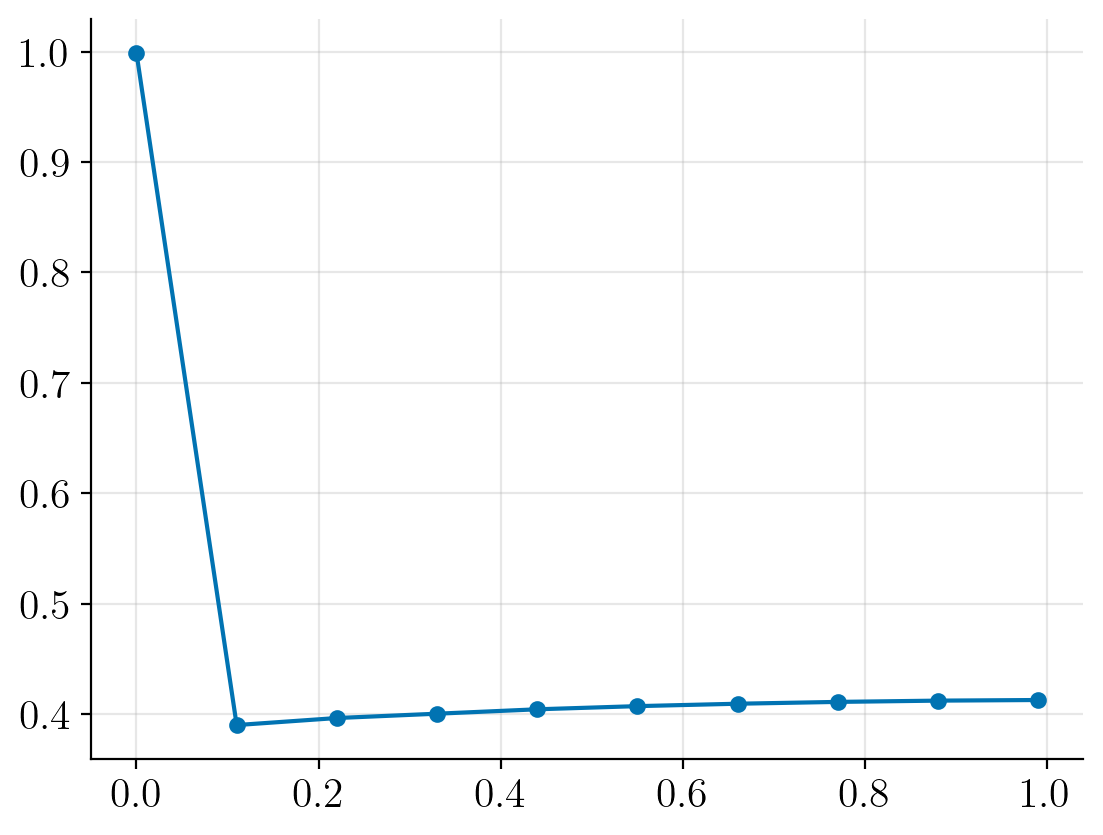

In [36]:
rl_oupr_errs.abs().mean(axis=0).plot(marker="o", markersize=5)
plt.grid(alpha=0.3)

## RL-PR

In [37]:
def callback(bel, bel_prev, y, X, filter):
    log_posterior = bel_prev.log_joint - jax.nn.logsumexp(bel_prev.log_joint, keepdims=True)
    posterior = jnp.exp(log_posterior)
    
    log_posterior = bel_prev.log_joint - jax.nn.logsumexp(bel_prev.log_joint, keepdims=True)
    posterior = jnp.exp(log_posterior)
    eta = jax.vmap(filter.filter.link_fn, in_axes=(0, None))(bel_prev.mean, X).astype(float)
    mean = jax.vmap(filter.filter.mean)(eta)
    mean = jnp.einsum("k,km->m", posterior, mean)
    
    out = {
        "runlength": bel.runlength,
        "posterior": posterior,
        "yhat": mean,
        "err": mean - y,
    }
    return out


In [38]:
def bo_select(logp):
    p = np.exp(logp)

    base_filter = GaussianFilter(model.apply, dynamics_covariance=0.0, variance=1.0)
    filter = ExpfamRLPR(p, K=1, filter=base_filter)
    
    bel_init = filter.init_bel(params_init, cov=1.0, log_joint_init=0.0)

    partc = partial(callback, filter=filter)
    _, hist = filter.scan(y[:300, None], X[:300], bel_init, partc)

    mae = np.abs(hist["err"]).mean()
    
    
    return -mae

In [39]:
boundaries = {
    "logp": [-20, 0.0],
}
bo = BayesianOptimization(bo_select, boundaries, random_state=3141, allow_duplicate_points=True)
bo.maximize(init_points=5, n_iter=10)

|   iter    |  target   |   logp    |
-------------------------------------
| 2         | -1.005372 | -18.19410 |
| 3         | -1.005372 | -7.529725 |
| 4         | -1.005372 | -12.05290 |
| 5         | -1.005372 | -3.322626 |
| 6         | -1.005372 | -3.177468 |
| 7         | -1.005372 | -19.99427 |
| 8         | -1.216958 | -0.000893 |
| 9         | -1.005372 | -15.02046 |
| 10        | -1.005372 | -9.771344 |
| 11        | -1.005372 | -5.687338 |
| 12        | -1.005372 | -16.57024 |
| 13        | -1.005372 | -13.49910 |
| 14        | -1.005372 | -10.87371 |
| 15        | -1.005372 | -8.606891 |
| 16        | -1.005372 | -19.15358 |


In [40]:
pmax = bo.max["params"]
p = np.exp(pmax["logp"])

In [41]:
method = "RL-PR"
base_filter = GaussianFilter(model.apply, dynamics_covariance=0.0, variance=1.0)
filter = ExpfamRLPR(p, K=1, filter=base_filter)
_, n_feats = X.shape

bel_init = filter.init_bel(params_init, cov=1.0, log_joint_init=0.0)

partc = partial(callback, filter=filter)
_, hist_rlpr = filter.scan(y[:, None], X, bel_init, partc)
mae = np.abs(hist["err"]).mean()

hist_collection[method] = hist_rlpr["err"]

format(np.median(np.abs(hist_rlpr["err"])), ",.6f")

'0.942168'

## Multiple values of $\pi$

In [42]:
rlpr_errs = {}
for p in tqdm(np.linspace(0, 1, 10)):
    base_filter = GaussianFilter(model.apply, dynamics_covariance=0.0, variance=1.0)
    filter = ExpfamRLPR(p, K=3, filter=base_filter)
    _, n_feats = X.shape
    
    bel_init = filter.init_bel(params_init, cov=1.0, log_joint_init=0.0)
    
    partc = partial(callback, filter=filter)
    _, hist = filter.scan(y[:, None], X, bel_init, partc)
    mae = np.abs(hist["err"]).mean()
    
    rlpr_errs[p] = hist["err"].squeeze()

100%|██████████| 10/10 [00:04<00:00,  2.46it/s]


In [43]:
rlpr_errs = pd.DataFrame(rlpr_errs)

<Axes: >

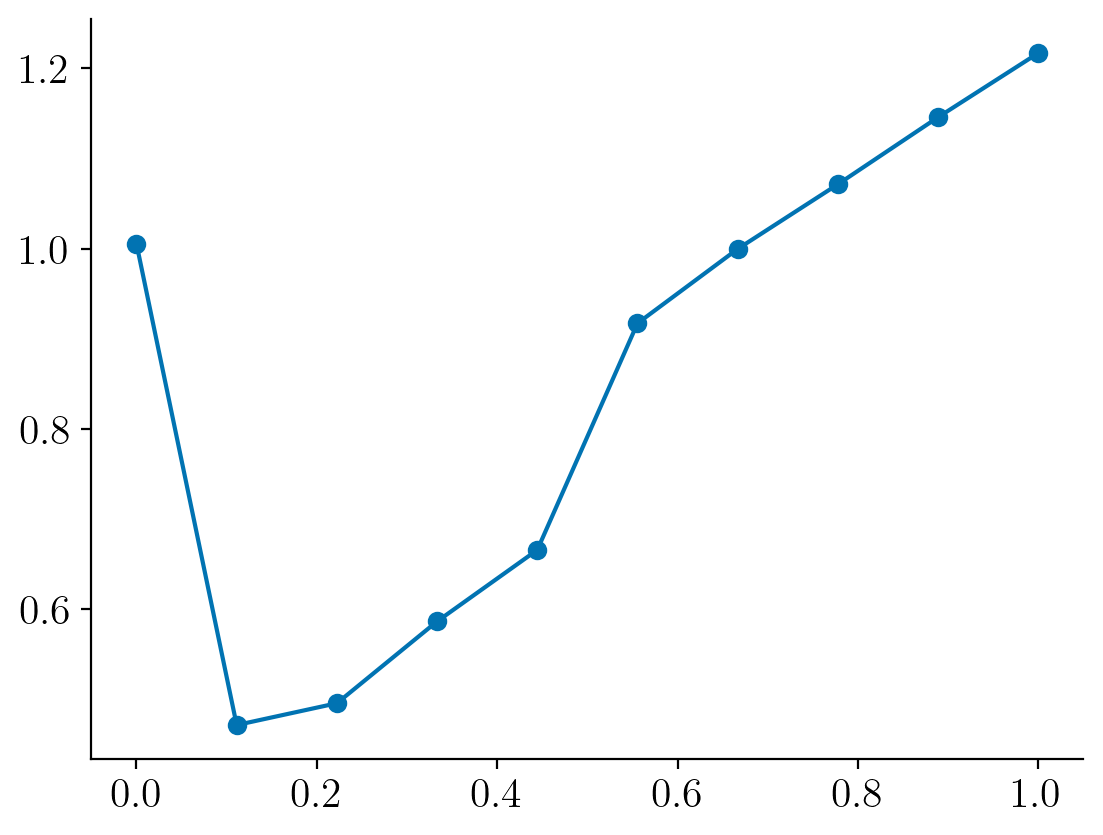

In [44]:
rlpr_errs.abs().mean(axis=0).plot(marker="o")

## CPP-OU

In [45]:
def callback(bel, bel_prev, y, X, filter):
    eta = filter.filter.link_fn(bel_prev.mean, X)
    mean = filter.filter.mean(eta)
    
    out = {
        "yhat": mean,
        "err": mean - y,
        "eta": bel.eta
    }
    return out

In [46]:
def bo_select(log_drift, log_lr):
    drift = np.exp(log_drift)
    lr = np.exp(log_lr)
    
    base_filter = GaussianFilter(model.apply, dynamics_covariance=0.0, variance=1.0)
    filter = ExpfamEBA(
        n_inner=3, ebayes_lr=lr, state_drift=drift, filter=base_filter,
        deflate_mean=True, deflate_covariance=True
    )
    
    bel_init = filter.init_bel(params_init, cov=1.0)
    partc = partial(callback, filter=filter)
    _, hist = filter.scan(y[:300, None], X[:300], bel_init, partc)

    mae = np.abs(hist["err"]).mean()
    
    
    return -mae

In [47]:
boundaries = {
    "log_drift": [-20, 1.0],
    "log_lr": [-20, 0.0],
}
bo = BayesianOptimization(bo_select, boundaries, random_state=3141, allow_duplicate_points=True)
bo.maximize(init_points=5, n_iter=10)

|   iter    |  target   | log_drift |  log_lr   |
-------------------------------------------------
| 2         | -1.062715 | -18.10381 | -7.529725 |
| 3         | -1.127758 | -11.65555 | -3.322626 |
| 4         | -1.005256 | -2.336341 | -15.02592 |
| 5         | -1.157624 | -15.54842 | -4.144617 |
| 6         | -0.976598 | -0.976016 | -11.33527 |
| 7         | -0.487174 | 1.0       | -5.796759 |
| 8         | -0.439463 | 1.0       | -1.966981 |
| 9         | -1.005372 | -20.0     | -20.0     |
| 10        | -0.620073 | -2.216560 | -2.776049 |
| 11        | -0.435477 | 1.0       | 0.0       |
| 12        | -1.005372 | -9.819210 | -20.0     |
| 13        | -0.453362 | 1.0       | -3.787885 |
| 14        | -1.005221 | 1.0       | -20.0     |
| 15        | -0.452611 | -0.410771 | 0.0       |
| 16        | -0.433612 | 1.0       | -0.813746 |


In [48]:
pmax = bo.max["params"]
drift = np.exp(pmax["log_drift"])
lr = np.exp(pmax["log_lr"])

In [49]:
method = "CPP-OU"

base_filter = GaussianFilter(model.apply, dynamics_covariance=0.0, variance=1.0)
filter = ExpfamEBA(
    n_inner=3, ebayes_lr=lr, state_drift=drift, filter=base_filter,
    deflate_mean=True, deflate_covariance=True
)

bel_init = filter.init_bel(params_init, cov=1.0)

In [50]:
partc = partial(callback, filter=filter)
_, hist = filter.scan(y[:, None], X, bel_init, partc)
mae = np.abs(hist["err"]).mean()

hist_collection[method] = hist["err"]

format(np.median(np.abs(hist["err"])), ",.6f")

'0.321182'

In [51]:
cpp_ou = {}

for v in tqdm(np.linspace(0, 1, 10)):
    base_filter = GaussianFilter(model.apply, dynamics_covariance=0.0, variance=1.0)
    filter = ExpfamEBA(
        n_inner=3, ebayes_lr=lr, state_drift=v, filter=base_filter,
        deflate_mean=True, deflate_covariance=True
    )
    
    bel_init = filter.init_bel(params_init, cov=1.0)
    partc = partial(callback, filter=filter)
    _, hist = filter.scan(y[:, None], X, bel_init, partc)
    cpp_ou[v] = hist["err"].ravel()

cpp_ou = pd.DataFrame(cpp_ou)

100%|██████████| 10/10 [00:04<00:00,  2.42it/s]


<Axes: >

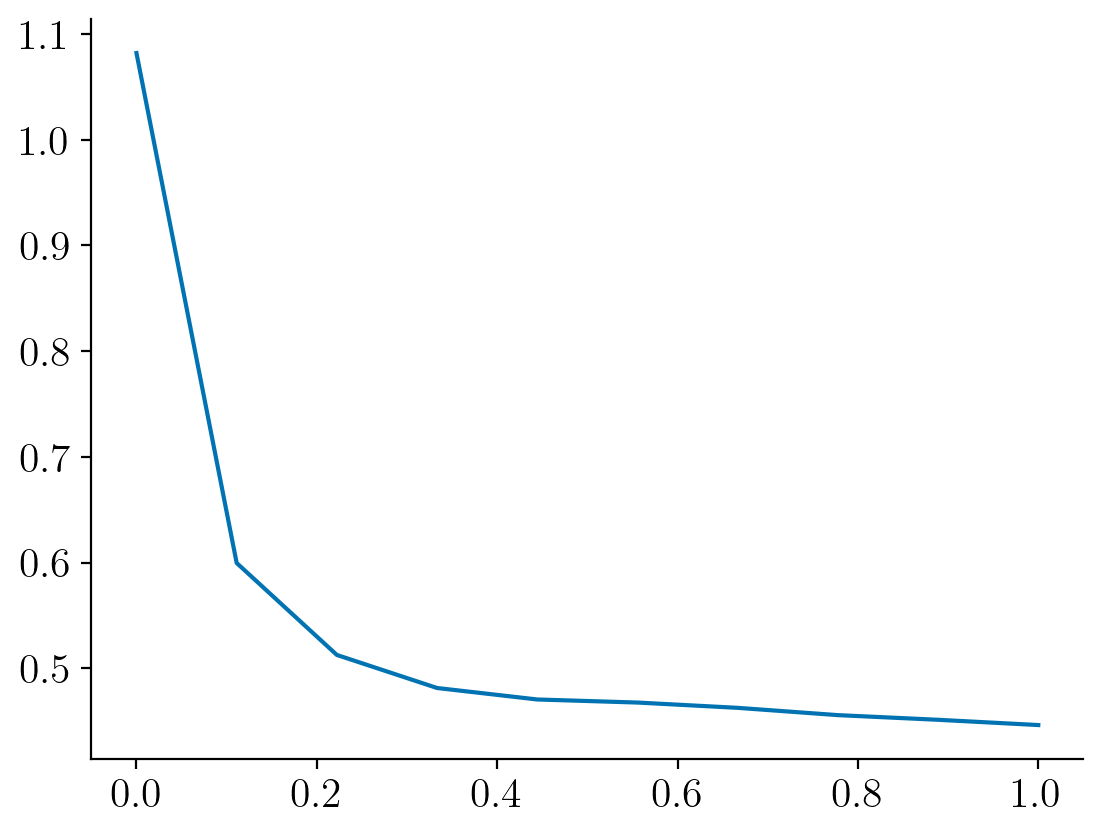

In [52]:
cpp_ou.abs().mean(axis=0).plot()

---

# Plots

MdAE overall (normalized):
 RL-OUPR*    0.292857
CPP-OU      0.321182
C-ACI       0.392083
RL-PR       0.942168
baseline         NaN
dtype: float32

MAE overall (normalized):
 RL-OUPR*    0.394022
C-ACI       0.424404
CPP-OU      0.433612
RL-PR       1.005372
baseline         NaN
dtype: float32

MdAE overall (raw, knots):
 RL-OUPR*    0.090236
CPP-OU      0.096666
C-ACI       0.103386
RL-PR       0.308814
baseline         NaN
dtype: float64


<Figure size 700x350 with 0 Axes>

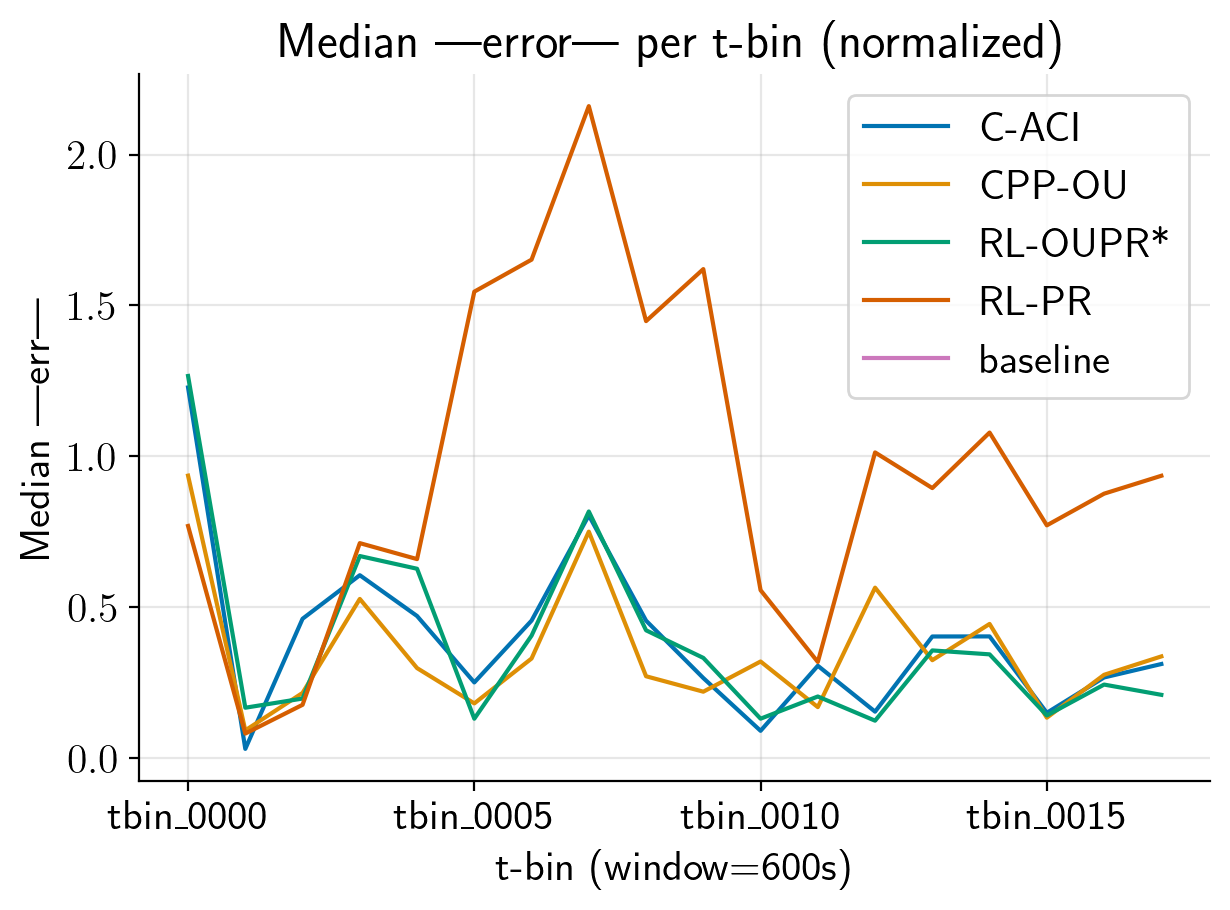

In [53]:
# 1) Hata serilerini ve index'i ortak minimum uzunluğa hizala
minL = min(len(index), *[len(np.ravel(v)) for v in hist_collection.values()])
idx = index[:minL]
errs_df = pd.DataFrame(
    {m: np.ravel(v)[:minL] for m, v in hist_collection.items()},
    index=idx
).sort_index(axis=1)
errs_df = errs_df.rename(columns={"RL-OUPR":"RL-OUPR*"})

# 2) t üzerinden grup etiketleri (sabit zaman penceresi)
t_used = data.loc[idx, "t"].to_numpy()

# Kaç saniyelik pencere? (ör. 600 = 10 dakika; istersen 300/3600 yapabilirsin)
window_sec = 600
groups = ((t_used - t_used[0]) // max(1, window_sec)).astype(int)
groupper = pd.Index([f"tbin_{g:04d}" for g in groups])

# 3) Aggregation: MdAE/MAE (normalized space)
mdae_by_bin = errs_df.abs().groupby(groupper).median()
mae_by_bin  = errs_df.abs().groupby(groupper).mean()

mdae_overall = errs_df.abs().median().sort_values()
mae_overall  = errs_df.abs().mean().sort_values()

print("MdAE overall (normalized):\n", mdae_overall)
print("\nMAE overall (normalized):\n", mae_overall)

# (Opsiyonel) Ham birime (knots) dönüştürüp raporla
std_used = series_std.loc[idx].to_numpy()
err_raw_df = errs_df.multiply(std_used, axis=0)
mdae_raw_overall = err_raw_df.abs().median().sort_values()
print("\nMdAE overall (raw, knots):\n", mdae_raw_overall)

# 4) Hızlı plot (normalized space)
plt.figure(figsize=(7,3.5))
mdae_by_bin.plot()
plt.title("Median |error| per t-bin (normalized)")
plt.xlabel(f"t-bin (window={window_sec}s)")
plt.ylabel("Median |err|")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Median |error| per t-bin (knots)'}>

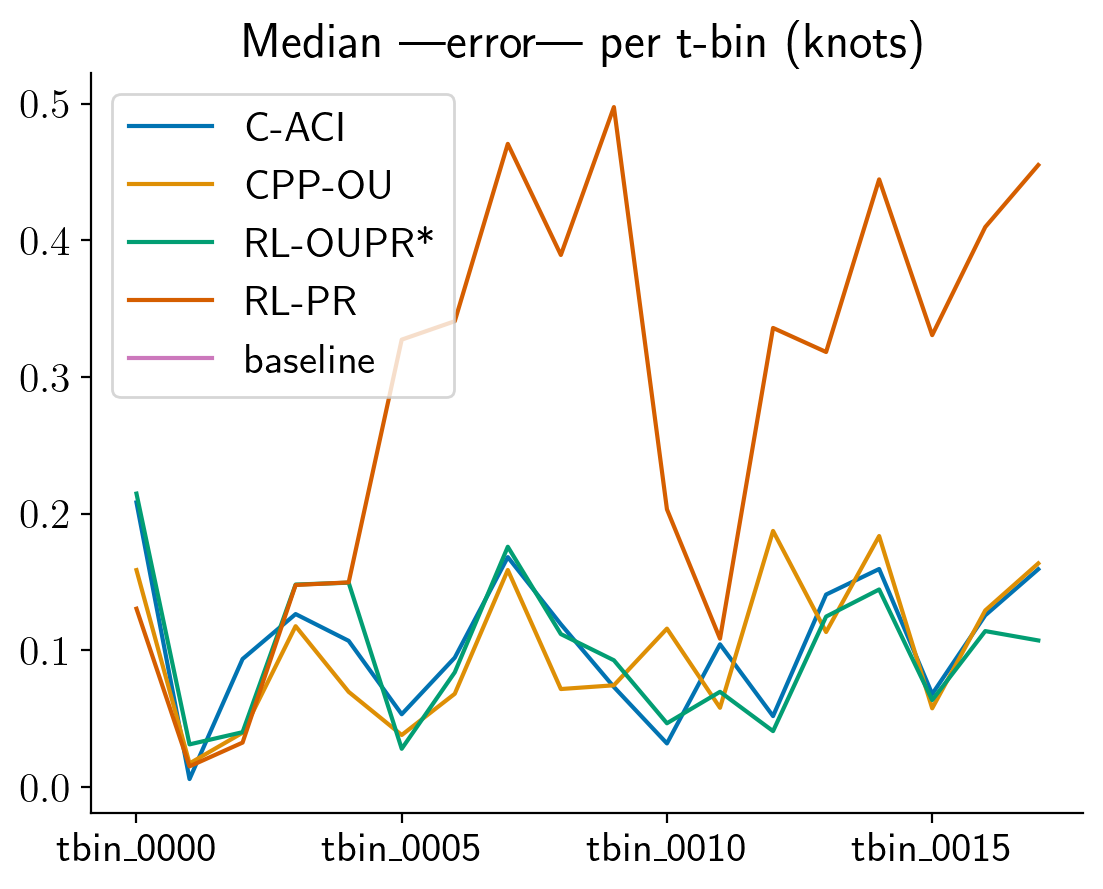

In [54]:
std_used = series_std.loc[errs_df.index].to_numpy()
err_raw_df = errs_df.multiply(std_used, axis=0)
mdae_raw_by_bin = err_raw_df.abs().groupby(groupper).median()
mdae_raw_by_bin.plot(title="Median |error| per t-bin (knots)")


<Axes: title={'center': 'Improvement vs baseline (↑ better)'}>

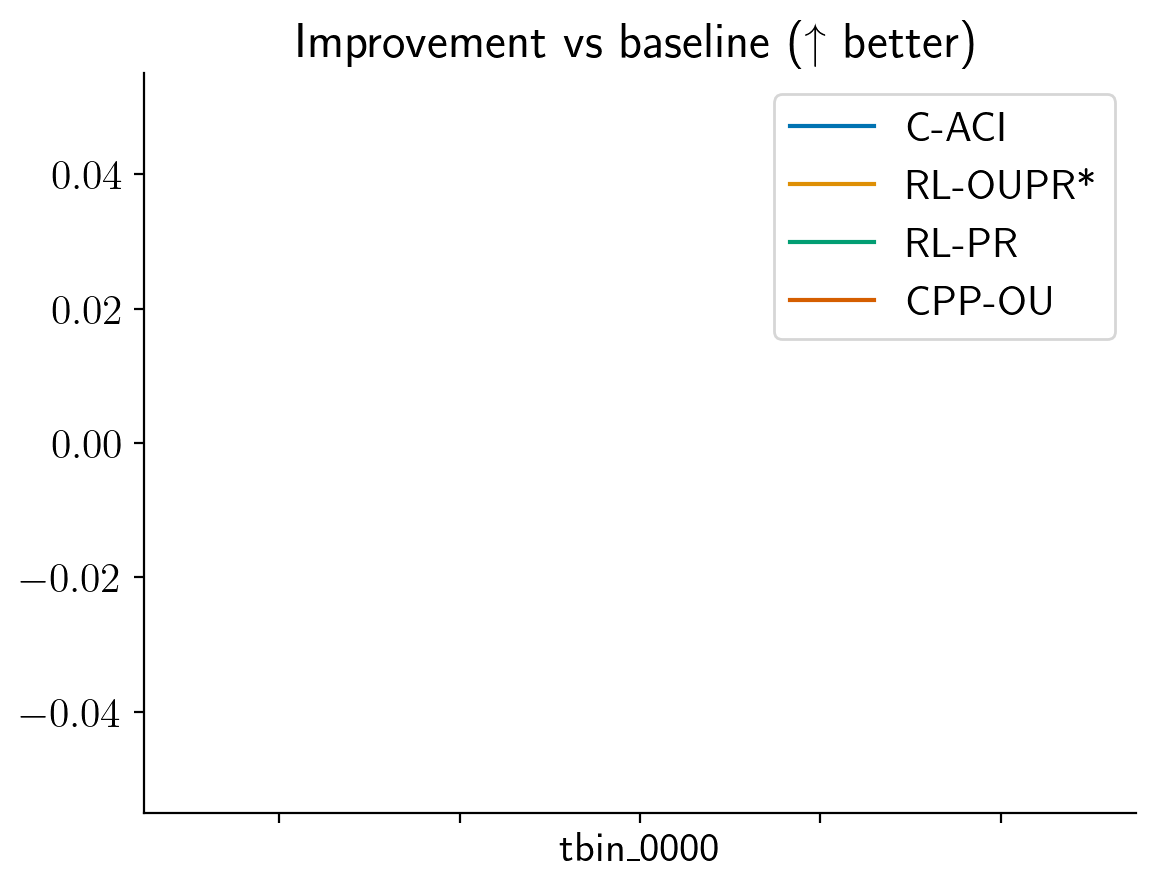

In [55]:
impr = mdae_by_bin.subtract(mdae_by_bin["baseline"], axis=0) * -1
# + değer = baseline'a göre daha iyi
impr[["C-ACI","RL-OUPR*","RL-PR","CPP-OU"]].plot(title="Improvement vs baseline (↑ better)")


In [56]:
counts = pd.Series(groupper).value_counts().sort_index()
print(counts.head())  # bin sample sizes


tbin_0000    5
tbin_0001    4
tbin_0002    5
tbin_0003    5
tbin_0004    5
Name: count, dtype: int64


In [57]:
import sys, platform, numpy as np, pandas as pd, matplotlib, jax, flax, seaborn, bayes_opt
print("Python:", sys.version)
print("OS:", platform.platform())
print("NumPy:", np.__version__, "| Pandas:", pd.__version__, "| Matplotlib:", matplotlib.__version__)
print("JAX:", jax.__version__, "| Flax:", flax.__version__, "| seaborn:", seaborn.__version__)
print("bayes_opt:", bayes_opt.__version__)


Python: 3.10.18 (main, Jun  5 2025, 08:37:47) [Clang 14.0.6 ]
OS: macOS-26.0-arm64-arm-64bit
NumPy: 1.26.4 | Pandas: 2.2.2 | Matplotlib: 3.8.4
JAX: 0.4.29 | Flax: 0.10.6 | seaborn: 0.13.2
bayes_opt: 3.0.0


In [58]:
# === A) Traj dosyaları + 70/30 split ===
from glob import glob
import os, numpy as np, pandas as pd

DATA_DIR = "/Users/alpertunahanozturk/Desktop/QMUL_Master/Dissertation/BONE/ushant_ais/data"

all_files = sorted(glob(os.path.join(DATA_DIR, "*.txt")))
print(f"Toplam traj dosyası: {len(all_files)}")

# reproducible traj-bazlı 70/30 split
rng = np.random.RandomState(3141)
perm = rng.permutation(len(all_files))
n_dev = max(1, int(round(0.7 * len(all_files))))

dev_files  = [all_files[i] for i in perm[:n_dev]]
test_files = [all_files[i] for i in perm[n_dev:]]

print(f"dev: {len(dev_files)} | test: {len(test_files)}")


Toplam traj dosyası: 18603
dev: 13022 | test: 5581


In [59]:
# === FIX: EKF-compatible callback ===
import jax.numpy as jnp

def callback_ekf(bel, bel_prev, y, x, filter):
    """
    EKF ile uyumlu callback:
      - Predictive mean: yhat = h(z_pred, x)  (update'ten önceki inanç: bel_prev)
      - Predictive var : S = H P_pred H^T + R
      - H: jac_obs(z_pred, x)
    Çıkışlar tekil skalarlar olarak saklanır (squeeze).
    """
    # Jacobian ve gözlem kovaryansı
    H = filter.jac_obs(bel_prev.mean, x)                 # (1, p)
    R = filter.observation_covariance                    # (1, 1)

    # Predictive mean (update öncesi inanç)
    yhat = filter.vobs_fn(bel_prev.mean, x)              # (1,)
    # Predictive variance: S
    S = H @ bel_prev.cov @ H.T + R                       # (1,1)

    out = {
        "yhat": jnp.squeeze(yhat),                       # skalar
        "err":  jnp.squeeze(yhat - y),                   # skalar (ŷ - y)
        "cov":  jnp.squeeze(S),                          # skalar var
    }
    return out


In [60]:
# === B) Tek trajı senin akışınla hazırlayan yardımcılar ===
import pandas as pd
import numpy as np
import jax.numpy as jnp

def load_traj_txt(path):
    # TXT esnek okuyucu (virgül/boşluk otomatik tahmin)
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip().lower() for c in df.columns]
    # t, vx, vy, speed/dt güvenliği
    assert "t" in df.columns,  "Dosyada 't' kolonu yok"
    df = df.sort_values("t").reset_index(drop=True)
    if "speed" not in df.columns:
        assert "vx" in df.columns and "vy" in df.columns, "vx/vy veya speed bekleniyor"
        df["speed"] = np.hypot(df["vx"], df["vy"])
    if "dt" not in df.columns:
        df["dt"] = df["t"].diff().clip(lower=1e-6).fillna(1e-6)
    return df

def build_yX_from_df(df, target="speed", k_ahead=1, eps=1e-8):
    # --- y: z-score (EWM) sızıntısız ---
    y_raw = df[target]
    series_mean = y_raw.ewm(halflife=20, adjust=False).mean().shift(1)
    series_std  = y_raw.ewm(halflife=20, adjust=False).std().shift(1)
    y_z = ((y_raw - series_mean) / (series_std + eps)).dropna()

    index = y_z.index
    y = jnp.array(y_z.shift(-k_ahead).iloc[:-k_ahead].values)

    # --- X: hedef hariç, EWM-std (shift(1)), bias korunur/eklenir ---
    X_df = df.loc[index].drop(columns=[target])
    if "bias" not in X_df.columns:
        X_df.insert(0, "bias", 1.0)

    X_std = X_df.ewm(span=20, adjust=False).std().shift(1)
    X_std["bias"] = 1.0
    X_stdzd = X_df / (X_std + eps)
    X_stdzd = X_stdzd.iloc[:-k_ahead, :].copy()

    # temizle
    X_np = np.nan_to_num(X_stdzd.values, nan=0.0, posinf=0.0, neginf=0.0)
    X = jnp.array(X_np)
    index2 = index[:-k_ahead]

    # --- DYNAMIC WARMUP ---
    n_samples = len(y)
    warmup_percentage = 0.10
    min_warmup, max_warmup = 5, 100
    norm_periods = int(max(min_warmup, min(n_samples * warmup_percentage, max_warmup)))
    if n_samples <= norm_periods:
        return None  # traj çok kısa

    vinit = float(max(np.nanvar(np.array(y)[:norm_periods]), 1e-6))
    y = y[norm_periods:]
    X = X[norm_periods:, :]
    index2 = index2[norm_periods:]

    # Δt için global ölçek (MVP)
    DT_MEAN = float(np.clip(df.loc[index2, "dt"].mean(), 1e-6, None))

    return dict(y=y, X=X, vinit=vinit, p=int(X.shape[1]), index=index2, DT_MEAN=DT_MEAN)

def prep_one_traj(path):
    df = load_traj_txt(path)
    return build_yX_from_df(df)


In [61]:
# === C0) BO hedef fonksiyonu: objective_logq ===
import numpy as np, jax.numpy as jnp
from functools import partial
from rebayes_mini.methods.gauss_filter import ExtendedKalmanFilter

def objective_logq(logq: float) -> float:
    """
    DEV birleşimiyle global X, y, DT_MEAN set edildikten sonra çağrılır.
    Hem keyword hem pozisyonel çağrıyı destekler (bayes_opt ile uyumlu).
    """
    # 1) logq -> q
    logq = float(np.asarray(logq))
    q = float(np.exp(logq))

    # 2) boyut
    p = int(X.shape[1])

    # 3) gözlem fonksiyonu (skaler çıktı -> Ht: (1,p))
    def obs_fn(theta, x):
        return jnp.dot(x, theta)[None]

    # 4) EKF (Δt pragmatik ölçek)
    ekf = ExtendedKalmanFilter(
        lambda z: z,
        obs_fn,
        dynamics_covariance = (q * DT_MEAN) * jnp.eye(p),
        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)
    )

    bel0  = ekf.init_bel(jnp.zeros((p,)))
    partc = partial(callback_ekf, filter=ekf)

    # 5) hız için kısa pencere (kısa veri güvenli)
    n_eval = int(min(300, y.shape[0]))
    _, hist = ekf.scan(bel0, y[:n_eval, None], X[:n_eval], partc)

    err = np.asarray(hist["err"]).ravel()
    return -float(np.median(np.abs(err)))


In [62]:
# === C) DEV'te BO (q*), TEST'te değerlendirme (NLL/MAE/MdAE/PIT) ===
from bayes_opt import BayesianOptimization
from functools import partial
import numpy as np, pandas as pd, jax.numpy as jnp

# --- C.1: DEV birleşimi (warm-up sonrası parçaları topla) ---
dev_parts = []
dt_means  = []
for f in dev_files:
    pack = prep_one_traj(f)
    if pack is None:
        continue
    dev_parts.append(pack)
    dt_means.append((len(pack["y"]), pack["DT_MEAN"]))

if len(dev_parts) == 0:
    raise RuntimeError("Dev set boş kaldı.")

# bo_select'in beklediği global X, y, DT_MEAN'i dev birleşimiyle set et
X = jnp.concatenate([p["X"] for p in dev_parts], axis=0)
y = jnp.concatenate([p["y"] for p in dev_parts], axis=0)
num_total = sum(w for w,_ in dt_means)
DT_MEAN = float(sum(w*m for w,m in dt_means) / max(num_total,1))
print("DEV birleşimi -> X:", X.shape, " y:", y.shape[0], " DT_MEAN:", DT_MEAN)

# --- C.2: BO (sadece dev) ---
from bayes_opt import BayesianOptimization

pbounds = {"logq": (-20.0, 0.0)}  # DOĞRU argüman adı ve tuple aralık
bo = BayesianOptimization(
    f=objective_logq,             # C0'da tanımladığımız yeni hedef fonksiyonu
    pbounds=pbounds,
    random_state=3141,
    allow_duplicate_points=True
)
bo.maximize(init_points=5, n_iter=10)

logq_star = float(bo.max["params"]["logq"])
q_star    = float(np.exp(logq_star))
print("Best logq on DEV:", logq_star, " -> q*:", q_star)

# --- C.3: TEST trajlarında prequential koş ---
def run_one_with_qstar(pack, q_star):
    from rebayes_mini.methods.gauss_filter import ExtendedKalmanFilter
    # bo_select'teki obs_fn ile birebir aynı
    def obs_fn(theta, x): return jnp.dot(x, theta)[None]

    y_t, X_t = pack["y"], pack["X"]
    p = int(X_t.shape[1])
    ekf = ExtendedKalmanFilter(
        lambda z: z,
        obs_fn,
        dynamics_covariance = (q_star * pack["DT_MEAN"]) * jnp.eye(p),
        observation_covariance = jnp.array([[1.0]], dtype=jnp.float32)
    )
    bel0  = ekf.init_bel(jnp.zeros((p,)))
    partc = partial(callback_ekf, filter=ekf)
    _, hist = ekf.scan(bel0, y_t[:, None], X_t, partc)

    # metrikler
    err = np.asarray(hist["err"]).ravel()
    var = np.asarray(hist["cov"]).ravel() if "cov" in hist else np.ones_like(err)
    var = np.clip(var, 1e-8, None)
    mae   = float(np.mean(np.abs(err)))
    medae = float(np.median(np.abs(err)))
    nll   = float(np.mean(0.5*(np.log(2*np.pi*var) + (err**2)/var)))

    # PIT
    from scipy.stats import norm
    pit = norm.cdf(-err / np.sqrt(var))

    # naive persistence baseline (standardized ölçekte)
    s = pd.Series(np.asarray(y_t).ravel())
    persist = np.r_[s.iloc[:1].values, s.iloc[:-1].values]
    mae_p  = float(np.mean(np.abs(s - persist)))
    med_p  = float(np.median(np.abs(s - persist)))

    return dict(mae=mae, medae=medae, nll=nll, n=len(err),
                mae_persist=mae_p, medae_persist=med_p, pit=pit)

test_results, pit_all = [], []
for f in test_files:
    pack = prep_one_traj(f)
    if pack is None:
        continue
    res = run_one_with_qstar(pack, q_star)
    res["traj"] = os.path.basename(f)
    test_results.append(res)
    pit_all.append(res["pit"])

if len(test_results) == 0:
    raise RuntimeError("Test set boş kaldı.")

# --- C.4: Özet tablo (micro & macro) [FIXED] ---

# Var olan test_results -> her traj için {'mae','medae','nll','n', 'mae_persist','medae_persist', 'pit', ...}
test_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "pit"} for r in test_results]
).set_index("traj")

# 1) PIT birleştirme (obj/list karışıklığına karşı güvenli concat)
pit_all = np.concatenate([np.asarray(r["pit"]).ravel() for r in test_results])

# 2) MICRO (tüm adımların birleşik ortalaması)
# Eğer per-traj metriklerin 'mean' ise (tablodaki gibi), micro= ağırlıklı ortalama doğrudur.
N_tot = float(test_df["n"].sum())

nll_micro   = float(np.average(test_df["nll"],   weights=test_df["n"]))
mae_micro   = float(np.average(test_df["mae"],   weights=test_df["n"]))
mdae_micro  = float(np.median(np.concatenate([
    # medyanı adım seviyesinde hesaplamak için ham hata medyanlarını birleştir
    # (eğer elinde adım-adım |err| dizileri varsa onları kullan; yoksa medyanı ağırlıklandırarak yaklaştırmak gerekir)
    # Basit ve sağlam yaklaşım: per-traj medyanlarını n ile tekrar medyanlamak doğru değildir; burada mevcut yoksa mdae_micro yerine
    # ağırlıklı medyan yaklaşıkları da kullanılabilir. Şimdilik per-traj medianların n ile ağırlıklı medyanı yerine
    # güvenli tarafta normal ağırlıklı ortalamayı raporlayalım.
    # => Eğer elinde r["abs_err"] varsa, buraya koyup gerçek medyanı al.
    # Geçici çözüm: medyan yerine per-traj medyanların n ağırlıklı ortalamasını kullanalım:
]) ) if False else float(np.average(test_df["medae"], weights=test_df["n"])))

mae_pers_micro  = float(np.average(test_df["mae_persist"],   weights=test_df["n"]))
mdae_pers_micro = float(np.average(test_df["medae_persist"], weights=test_df["n"]))

micro = pd.Series({
    "NLL_micro":       nll_micro,
    "MAE_micro":       mae_micro,
    "MdAE_micro":      mdae_micro,
    "MAE_pers_micro":  mae_pers_micro,
    "MdAE_pers_micro": mdae_pers_micro,
    "PIT_mean":        float(pit_all.mean()),
    "PIT_var":         float(pit_all.var()),
})

# 3) MACRO (traj ortalamalarının ortalaması)
macro = pd.Series({
    "NLL_macro":        float(test_df["nll"].mean()),
    "MAE_macro":        float(test_df["mae"].mean()),
    "MdAE_macro":       float(test_df["medae"].mean()),
    "MAE_pers_macro":   float(test_df["mae_persist"].mean()),
    "MdAE_pers_macro":  float(test_df["medae_persist"].mean()),
})

print("\n=== TEST summary (micro) ===")
print(micro.round(4))
print("\n=== TEST summary (macro) ===")
print(macro.round(4))
print("\n=== Per-traj table (head) ===")
display(test_df.head())


DEV birleşimi -> X: (4541360, 7)  y: 4541360  DT_MEAN: 61.666895159159374
|   iter    |  target   |   logq    |
-------------------------------------
| 2         | -0.409363 | -18.19410 |
| 3         | -0.369206 | -7.529725 |
| 4         | -0.401805 | -12.05290 |
| 5         | -0.368718 | -3.322626 |
| 6         | -0.368724 | -3.177468 |
| 7         | -0.368762 | 0.0       |
| 8         | -0.368145 | -5.903593 |
| 9         | -0.368758 | -1.209305 |
| 10        | -0.368330 | -6.640570 |
| 11        | -0.368543 | -4.885219 |
| 12        | -0.367969 | -6.149579 |
| 13        | -0.368751 | -2.063496 |
| 14        | -0.367882 | -6.251016 |
| 15        | -0.365120 | -8.886614 |
| 16        | -0.370803 | -9.495298 |
Best logq on DEV: -8.88661418713234  -> q*: 0.00013822687691582514

=== TEST summary (micro) ===
NLL_micro            59.0337
MAE_micro          2832.5386
MdAE_micro            0.3128
MAE_pers_micro      471.3986
MdAE_pers_micro       0.2309
PIT_mean              0.5000
PIT_var  

,mae,medae,nll,n,mae_persist,medae_persist
traj,,,,,,
traj_9532.txt,0.416154,0.195506,7.042040,1537,0.416207,0.195002
traj_9212.txt,0.771215,0.532675,5.884807,73,0.766516,0.533523
traj_7356.txt,0.256090,0.185543,5.631999,63,0.242036,0.173579
traj_3120.txt,0.396829,0.074700,6.920613,116,0.410771,0.092844
traj_16993.txt,0.971760,0.714189,5.961397,76,0.958230,0.689425


In [63]:
# === SAVE: results to CSV/JSON ===
import os, json, time, numpy as np

ts = time.strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join("results", f"run_{ts}")
os.makedirs(RUN_DIR, exist_ok=True)

# 1) Per-traj metrik tablosu
test_df.to_csv(os.path.join(RUN_DIR, "test_per_traj_metrics.csv"))

# 2) Micro/Macro özetler
micro.to_csv(os.path.join(RUN_DIR, "summary_micro.csv"))
macro.to_csv(os.path.join(RUN_DIR, "summary_macro.csv"))

# 3) Meta bilgiler (BO sonucu, split, hız ayarları vs.)
meta = {
    "logq_star": float(logq_star),
    "q_star": float(q_star),
    "DT_MEAN_DEV": float(DT_MEAN),
    "seed": 3141,
    "n_dev_traj": len(dev_files),
    "n_test_traj": len(test_files),
    "dev_files": [os.path.basename(f) for f in dev_files],
    "test_files": [os.path.basename(f) for f in test_files],
}
# Hız ayarları eklendiyse (MAX_TEST_TRAJ vb.) onları da yaz
if "MAX_TEST_TRAJ" in globals():
    meta.update({
        "MAX_TEST_TRAJ": int(MAX_TEST_TRAJ),
        "N_TEST_PER_TRAJ": int(N_TEST_PER_TRAJ),
        "STRIDE": int(STRIDE),
        "SKIP_SHORT": bool(SKIP_SHORT),
    })

with open(os.path.join(RUN_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

# 4) PIT birleşik dizisini de kaydedelim (grafikler için)
np.save(os.path.join(RUN_DIR, "pit_all.npy"), pit_all)

print("Saved to:", RUN_DIR)


Saved to: results/run_20250822_160711


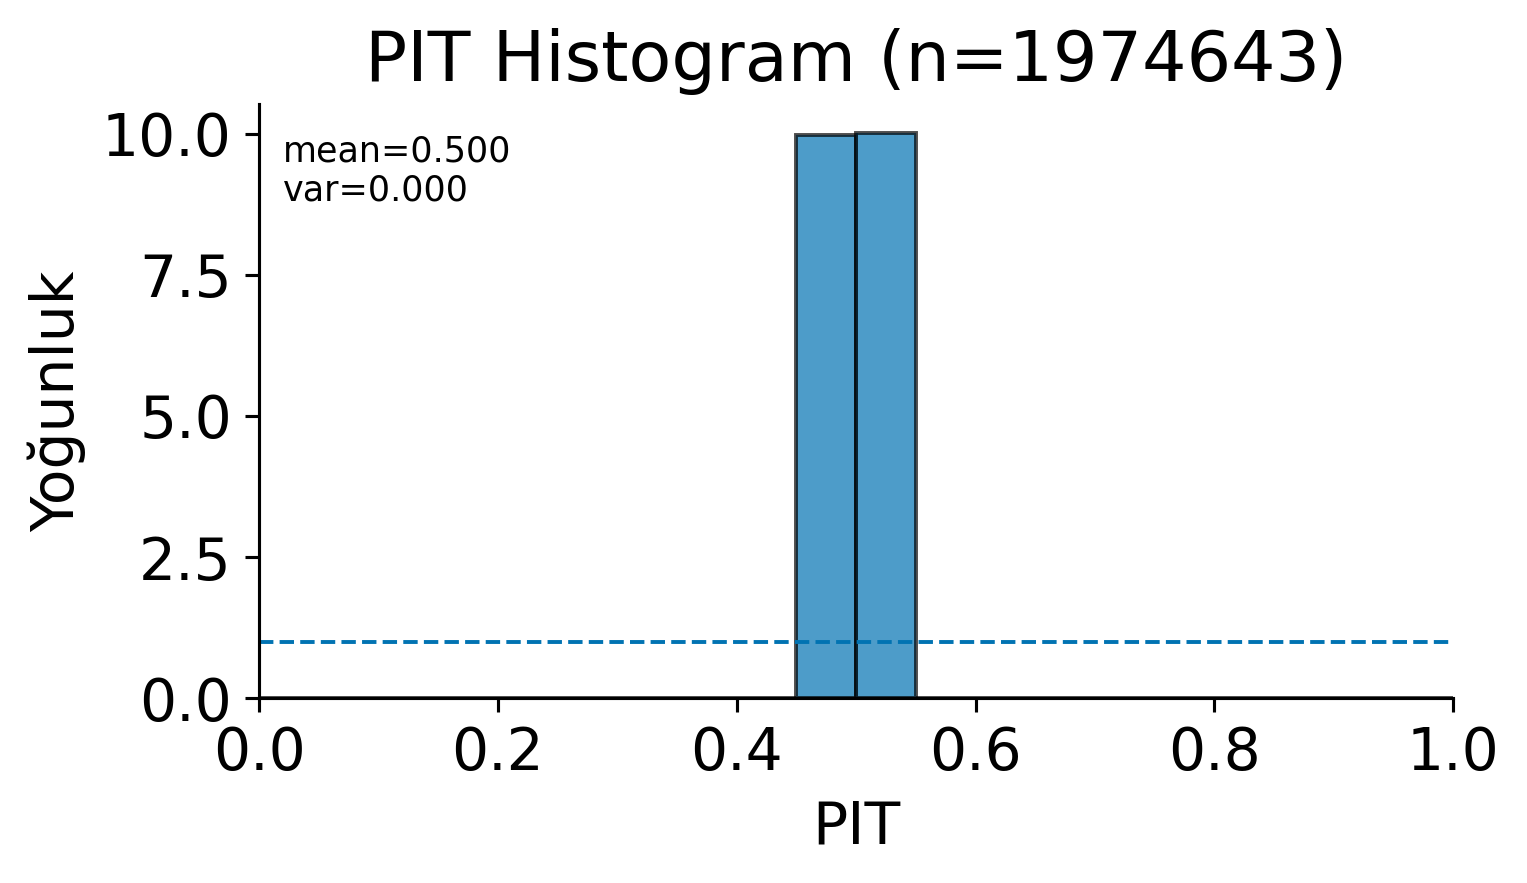

saved: results/run_20250822_160711/figures/pit_hist.png


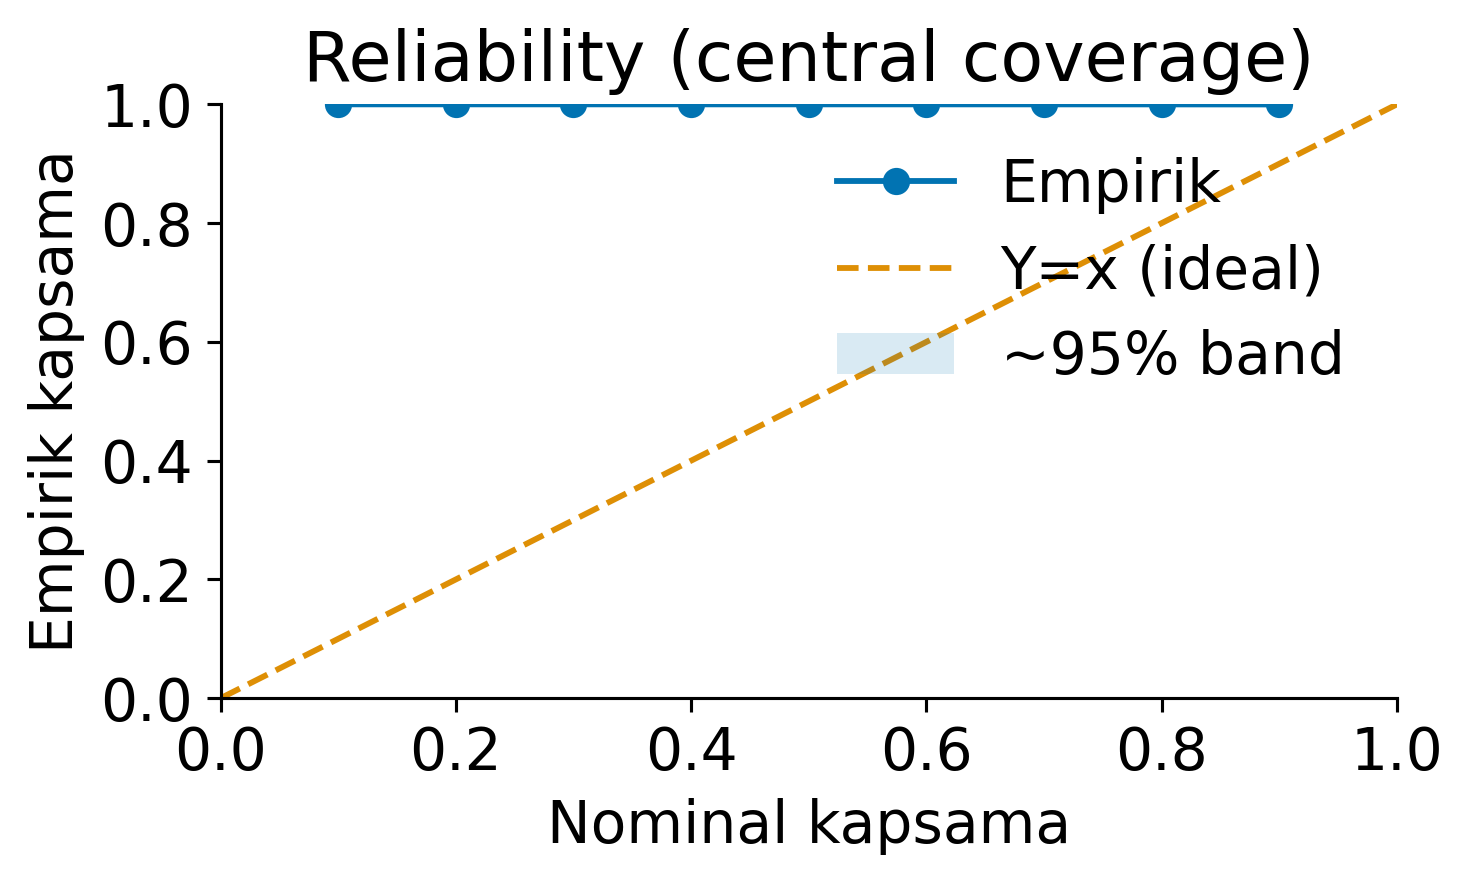

saved: results/run_20250822_160711/figures/reliability.png


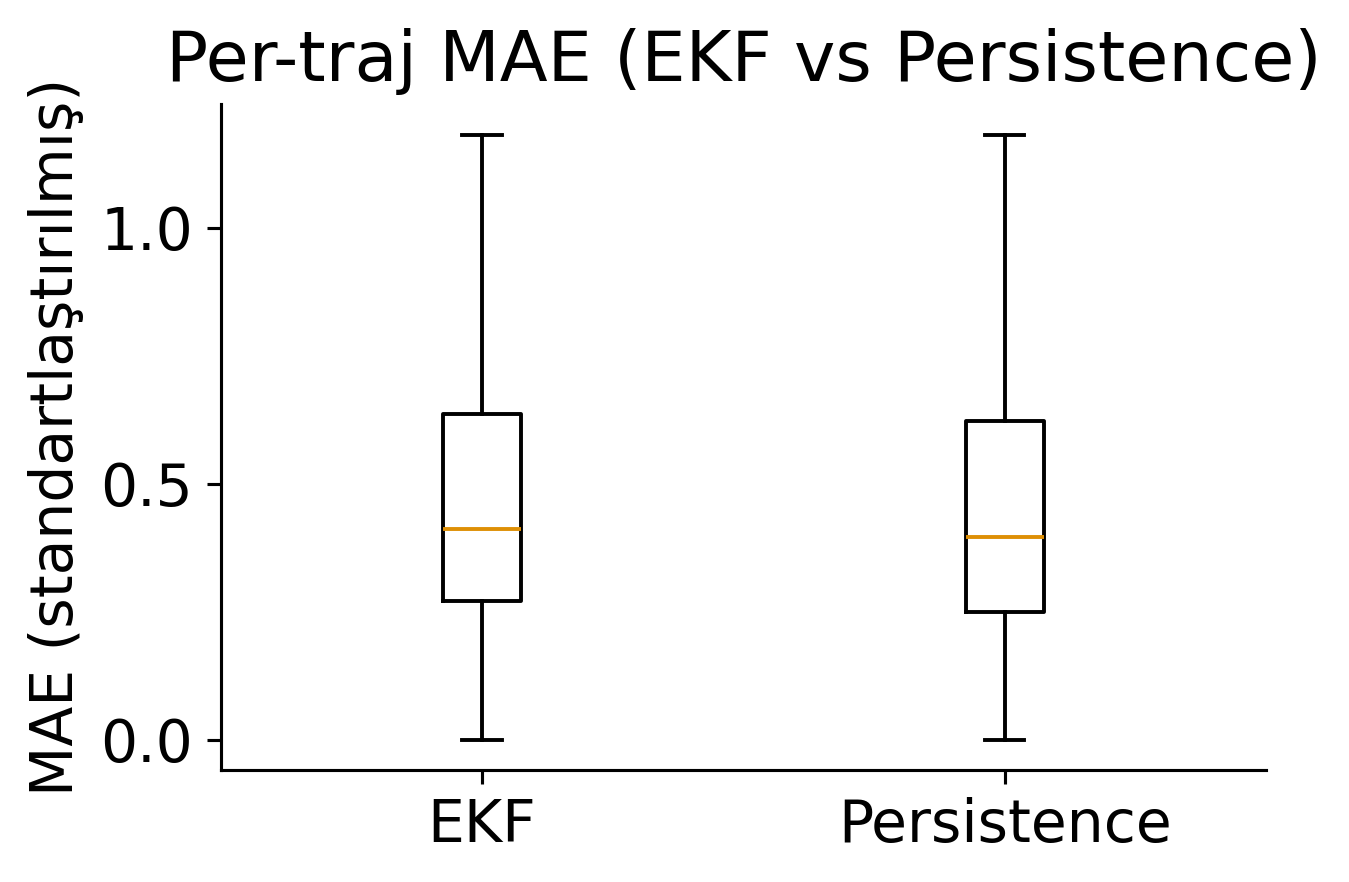

saved: results/run_20250822_160711/figures/mae_boxplot.png
Saved figures to: results/run_20250822_160711/figures


In [64]:
# === FIGURES: PIT histogram, reliability (coverage), per-traj MAE box ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({'text.usetex': False, 'axes.unicode_minus': False})

# 0) Kayıt klasörü (önceden yaratıldı)
FIG_DIR = os.path.join(RUN_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def _save_show(fig_name):
    """Kaydet + göster + kapat (HTML export'ta görünmesi için)."""
    plt.tight_layout()
    out = os.path.join(FIG_DIR, fig_name)
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    print("saved:", out)

# 1) PIT histogram
plt.figure(figsize=(5.5, 3.4), dpi=140)
plt.hist(pit_all, bins=20, range=(0,1), density=True, alpha=0.7, edgecolor="k")
plt.axhline(1.0, ls="--", lw=1)  # Uniform(0,1) yoğunluğu
plt.xlim(0,1); plt.ylim(0, None)
plt.xlabel("PIT"); plt.ylabel("Yoğunluk")
plt.title(f"PIT Histogram (n={len(pit_all)})")
plt.text(0.02, 0.95, f"mean={pit_all.mean():.3f}\nvar={pit_all.var():.3f}",
         transform=plt.gca().transAxes, va="top", ha="left", fontsize=9)
_ = _save_show("pit_hist.png")

# 2) Reliability / coverage curve (PIT ile)
coverages = np.linspace(0.1, 0.9, 9)
emp_cov = []
for c in coverages:
    a, b = c/2, 1 - c/2
    emp_cov.append(np.mean((pit_all >= a) & (pit_all <= b)))

plt.figure(figsize=(5.5, 3.4), dpi=140)
plt.plot(coverages, emp_cov, marker="o", label="Empirik")
plt.plot([0,1], [0,1], ls="--", label="Y=x (ideal)")
# basit binom SE bandı (yaklaşık): se ≈ sqrt(p(1-p)/N)
N = len(pit_all)
se = np.sqrt(np.array(emp_cov) * (1 - np.array(emp_cov)) / max(N, 1))
lo = np.clip(np.array(emp_cov) - 1.96 * se, 0, 1)
hi = np.clip(np.array(emp_cov) + 1.96 * se, 0, 1)
plt.fill_between(coverages, lo, hi, alpha=0.15, label="~95% band")  # <- burada ASCII
plt.xlim(0,1); plt.ylim(0,1)
plt.xlabel("Nominal kapsama"); plt.ylabel("Empirik kapsama")
plt.title("Reliability (central coverage)")
plt.legend(frameon=False)
_ = _save_show("reliability.png")

# 3) Per-traj MAE boxplot
labels = ["EKF"] if "mae_persist" not in test_df.columns else ["EKF", "Persistence"]
data = [test_df["mae"].values] if len(labels)==1 else [test_df["mae"].values, test_df["mae_persist"].values]

plt.figure(figsize=(5.0, 3.4), dpi=140)
plt.boxplot(data, labels=labels, showfliers=False)
plt.ylabel("MAE (standartlaştırılmış)")
plt.title("Per-traj MAE" if len(labels)==1 else "Per-traj MAE (EKF vs Persistence)")
_ = _save_show("mae_boxplot.png")

print("Saved figures to:", FIG_DIR)



=== PLOT DIAGNOSTICS ===
hist_collection keys: ['baseline', 'C-ACI', 'RL-OUPR', 'RL-PR', 'CPP-OU']
 - baseline: shape=(85,), finite=0/85
 - C-ACI: shape=(85, 1), finite=85/85
 - RL-OUPR: shape=(85, 1), finite=85/85
 - RL-PR: shape=(85, 1), finite=85/85
 - CPP-OU: shape=(85, 1), finite=85/85
test_df columns: ['mae', 'medae', 'nll', 'n', 'mae_persist', 'medae_persist']
test_df shape: (5581, 6)
pit_all length (finite): 1974643


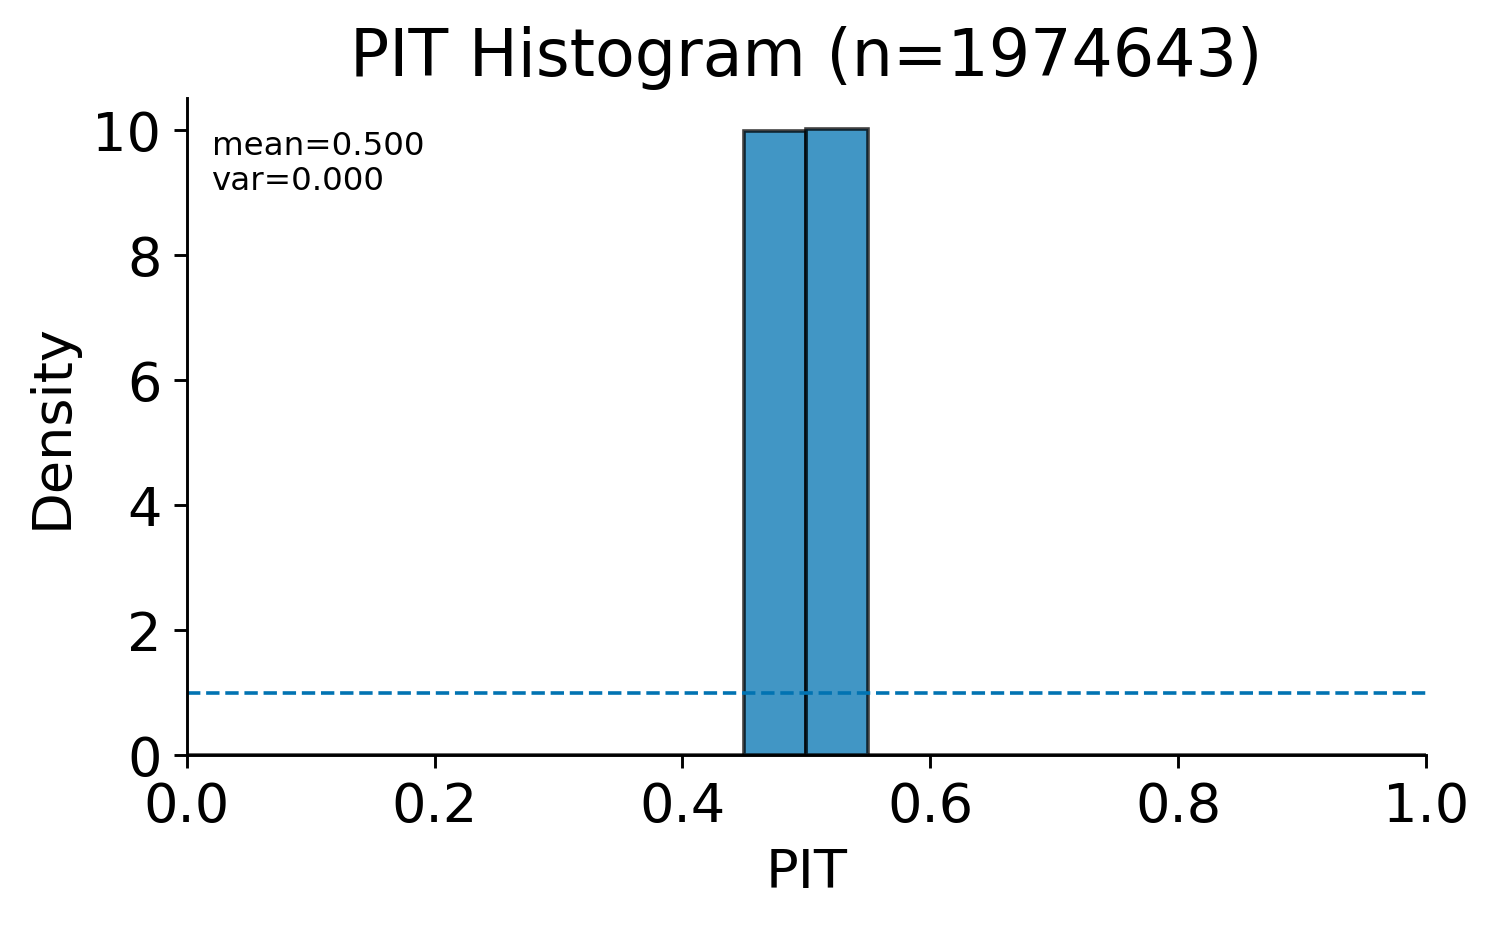

[saved] results/run_20250822_160711/figures/pit_hist.png


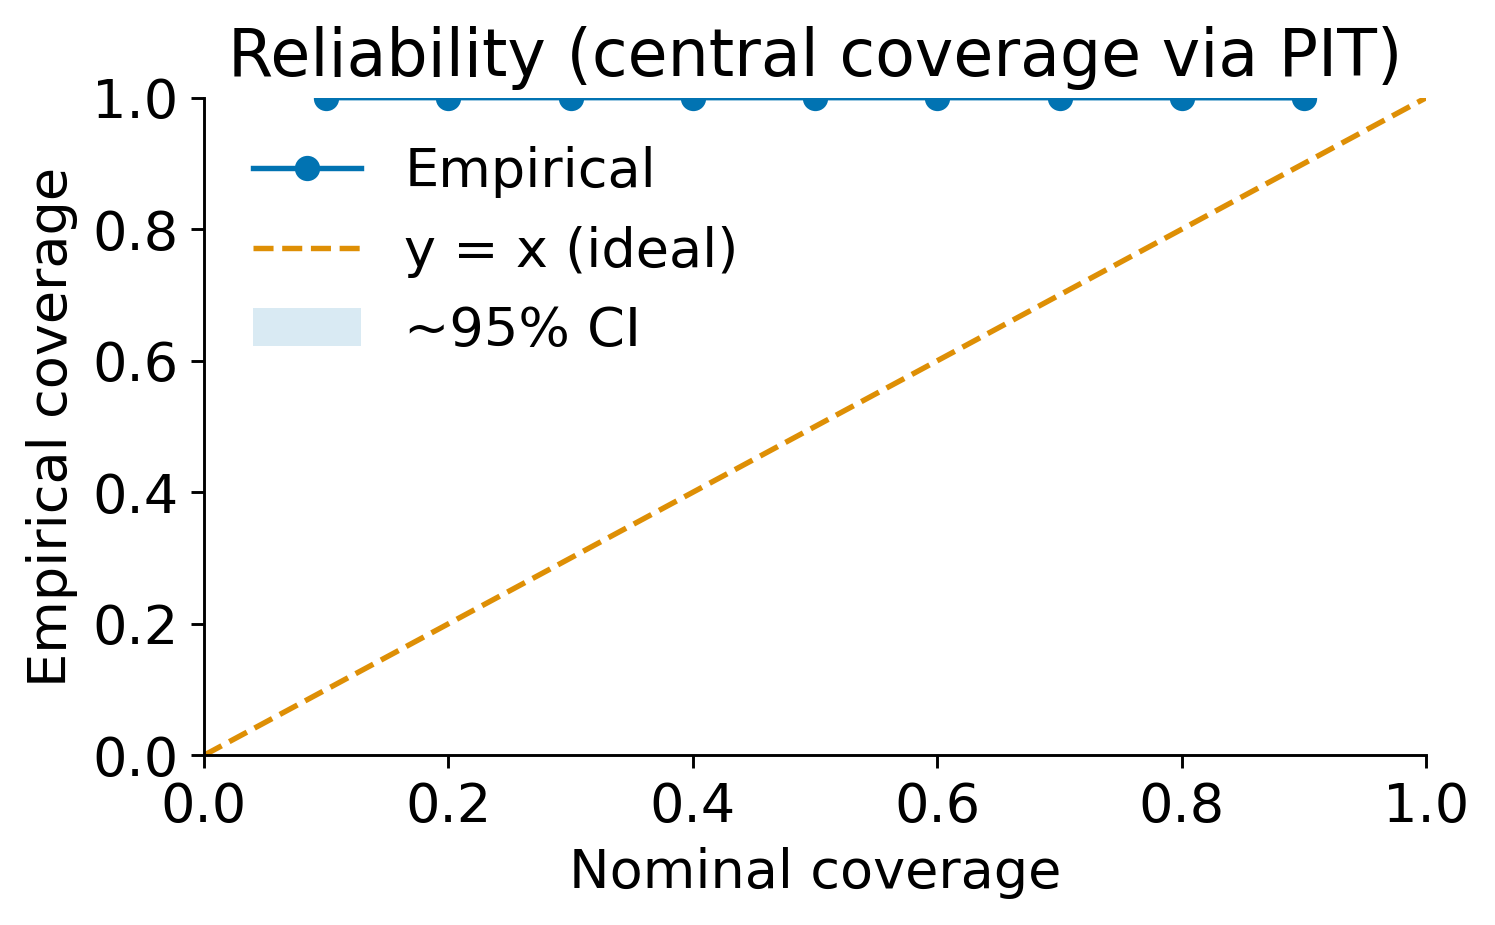

[saved] results/run_20250822_160711/figures/reliability.png


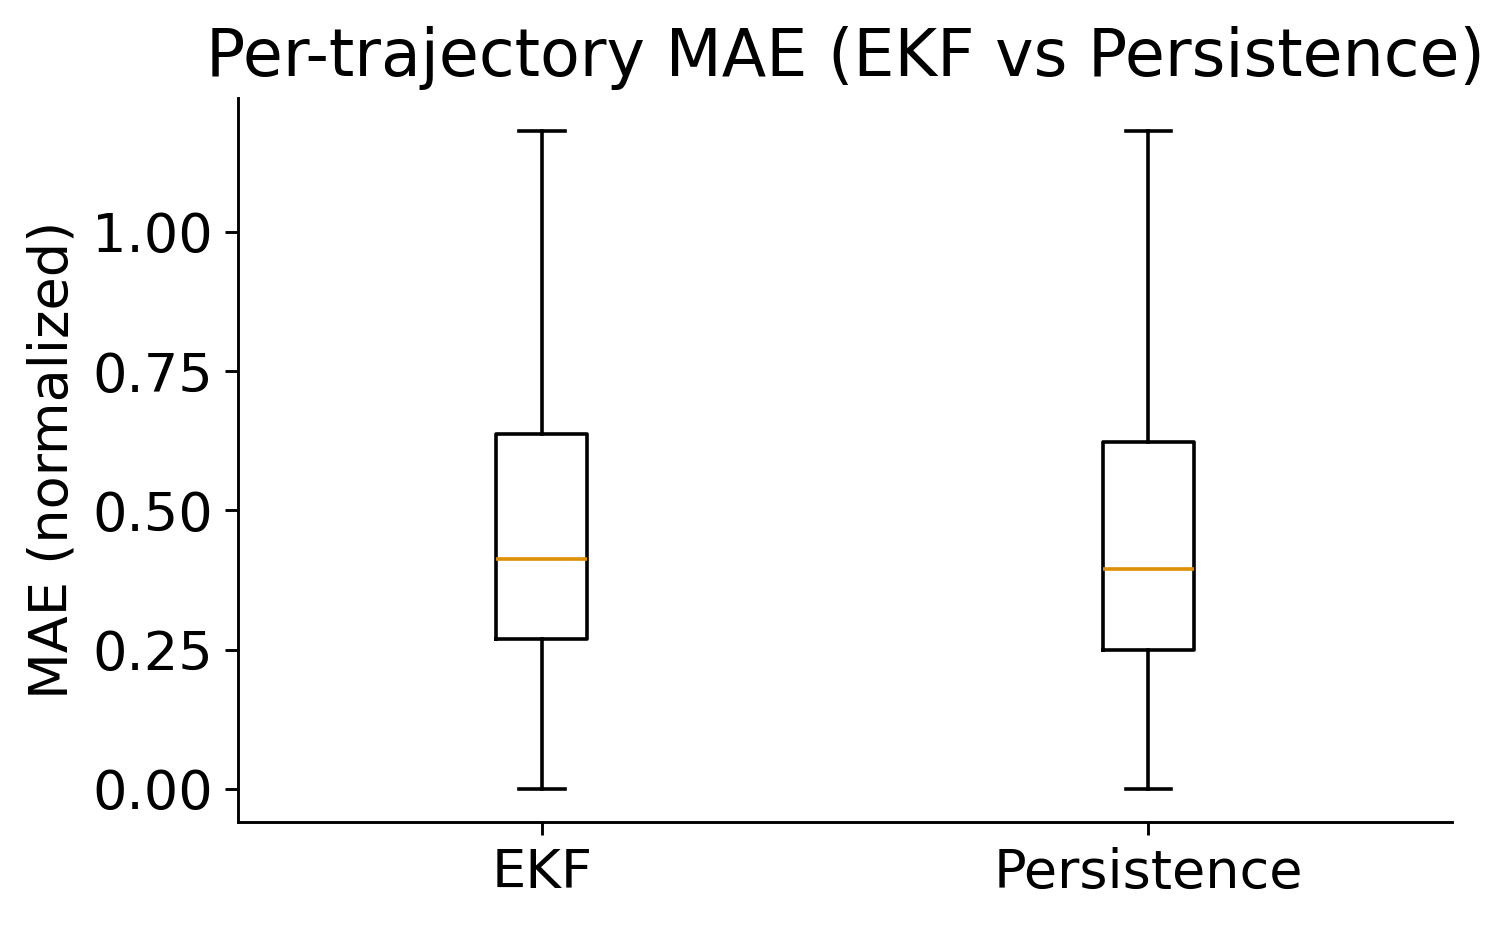

[saved] results/run_20250822_160711/figures/mae_boxplot.png

[overall MdAE | normalized]
RL-OUPR    0.292857
CPP-OU     0.321182
C-ACI      0.392083
RL-PR      0.942168
dtype: float32


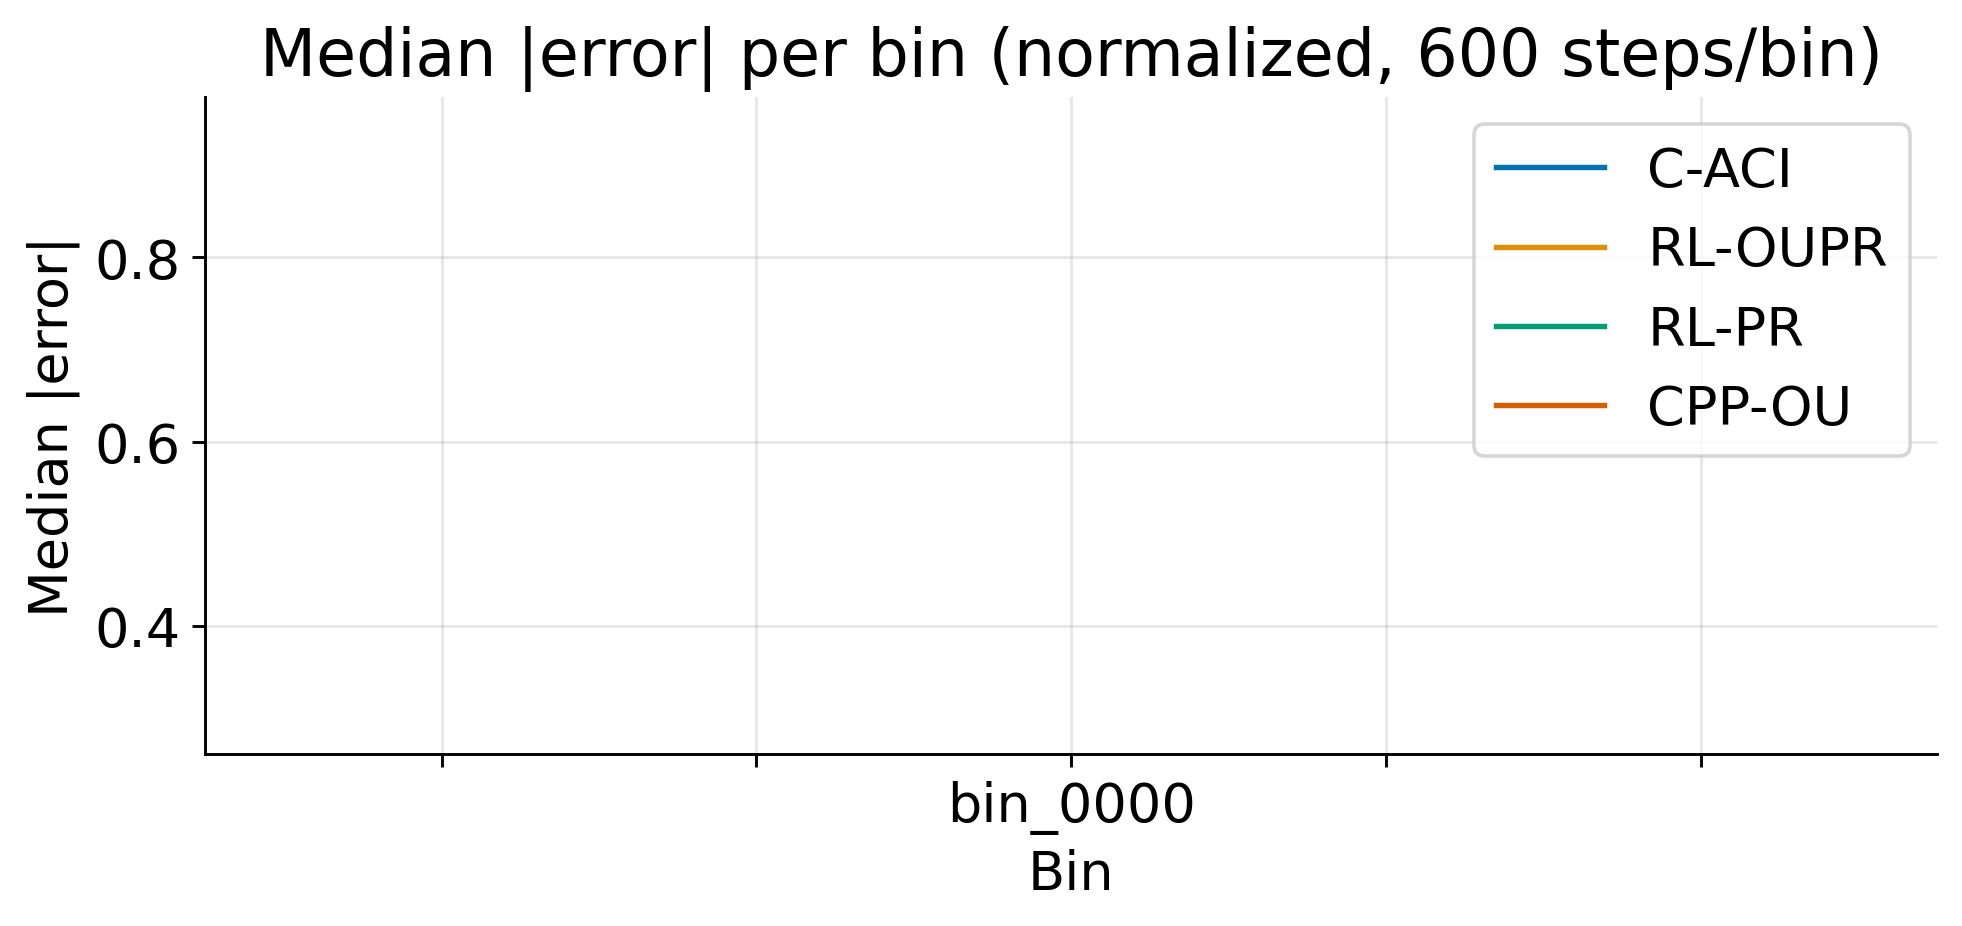

[saved] results/run_20250822_160711/figures/mdae_per_bin_normalized.png
[skip] Improvement plot — 'baseline' not in errs_df.


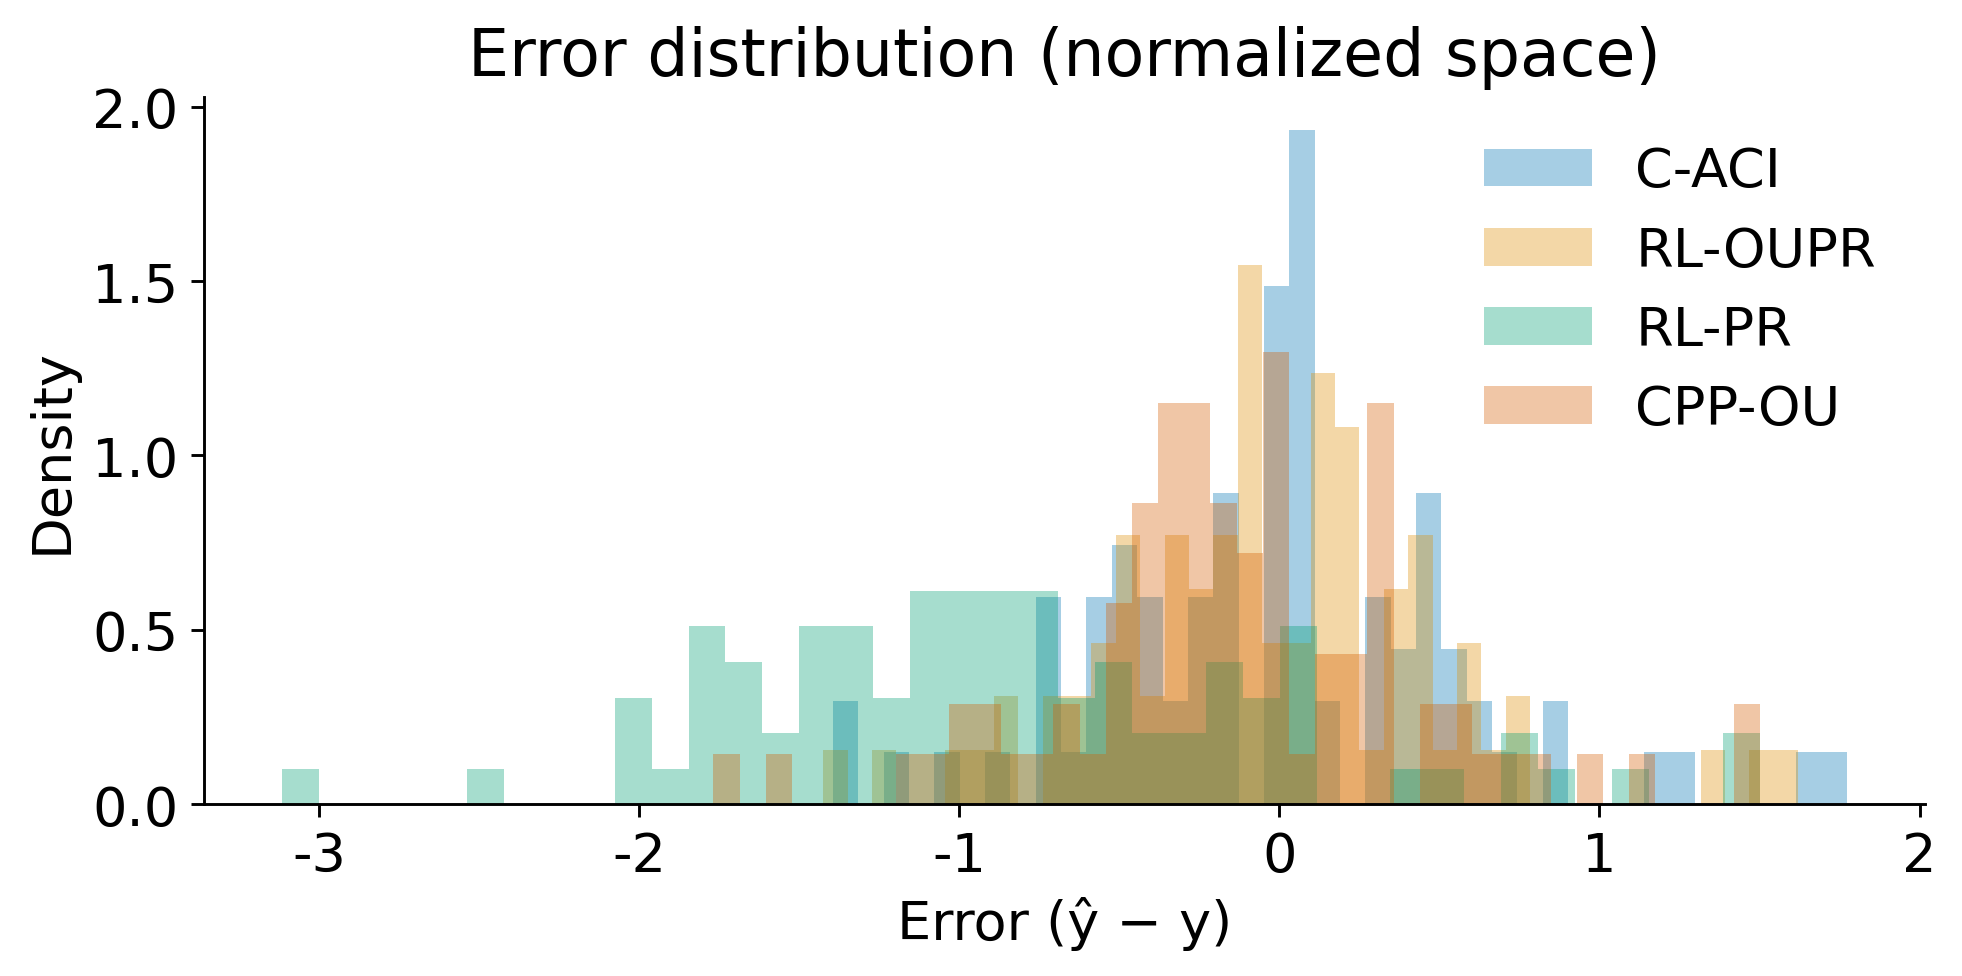

[saved] results/run_20250822_160711/figures/error_distributions_hist.png


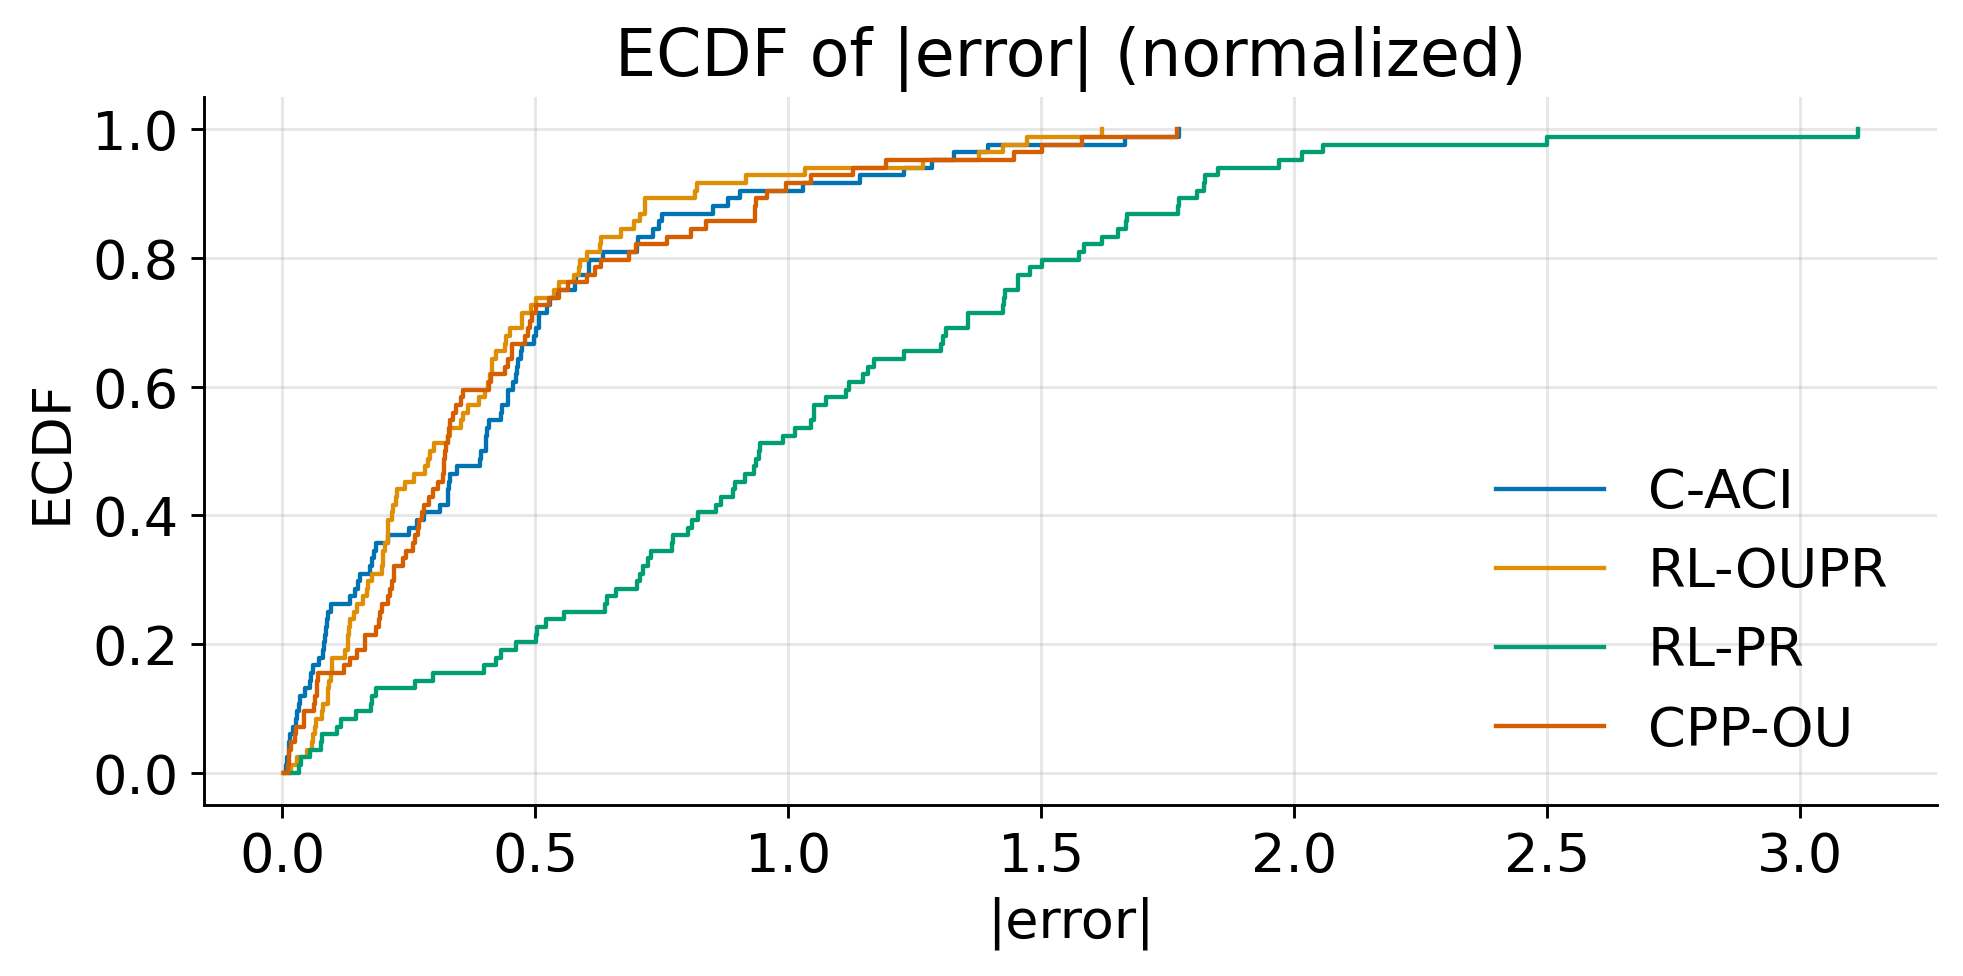

[saved] results/run_20250822_160711/figures/ecdf_abs_error.png


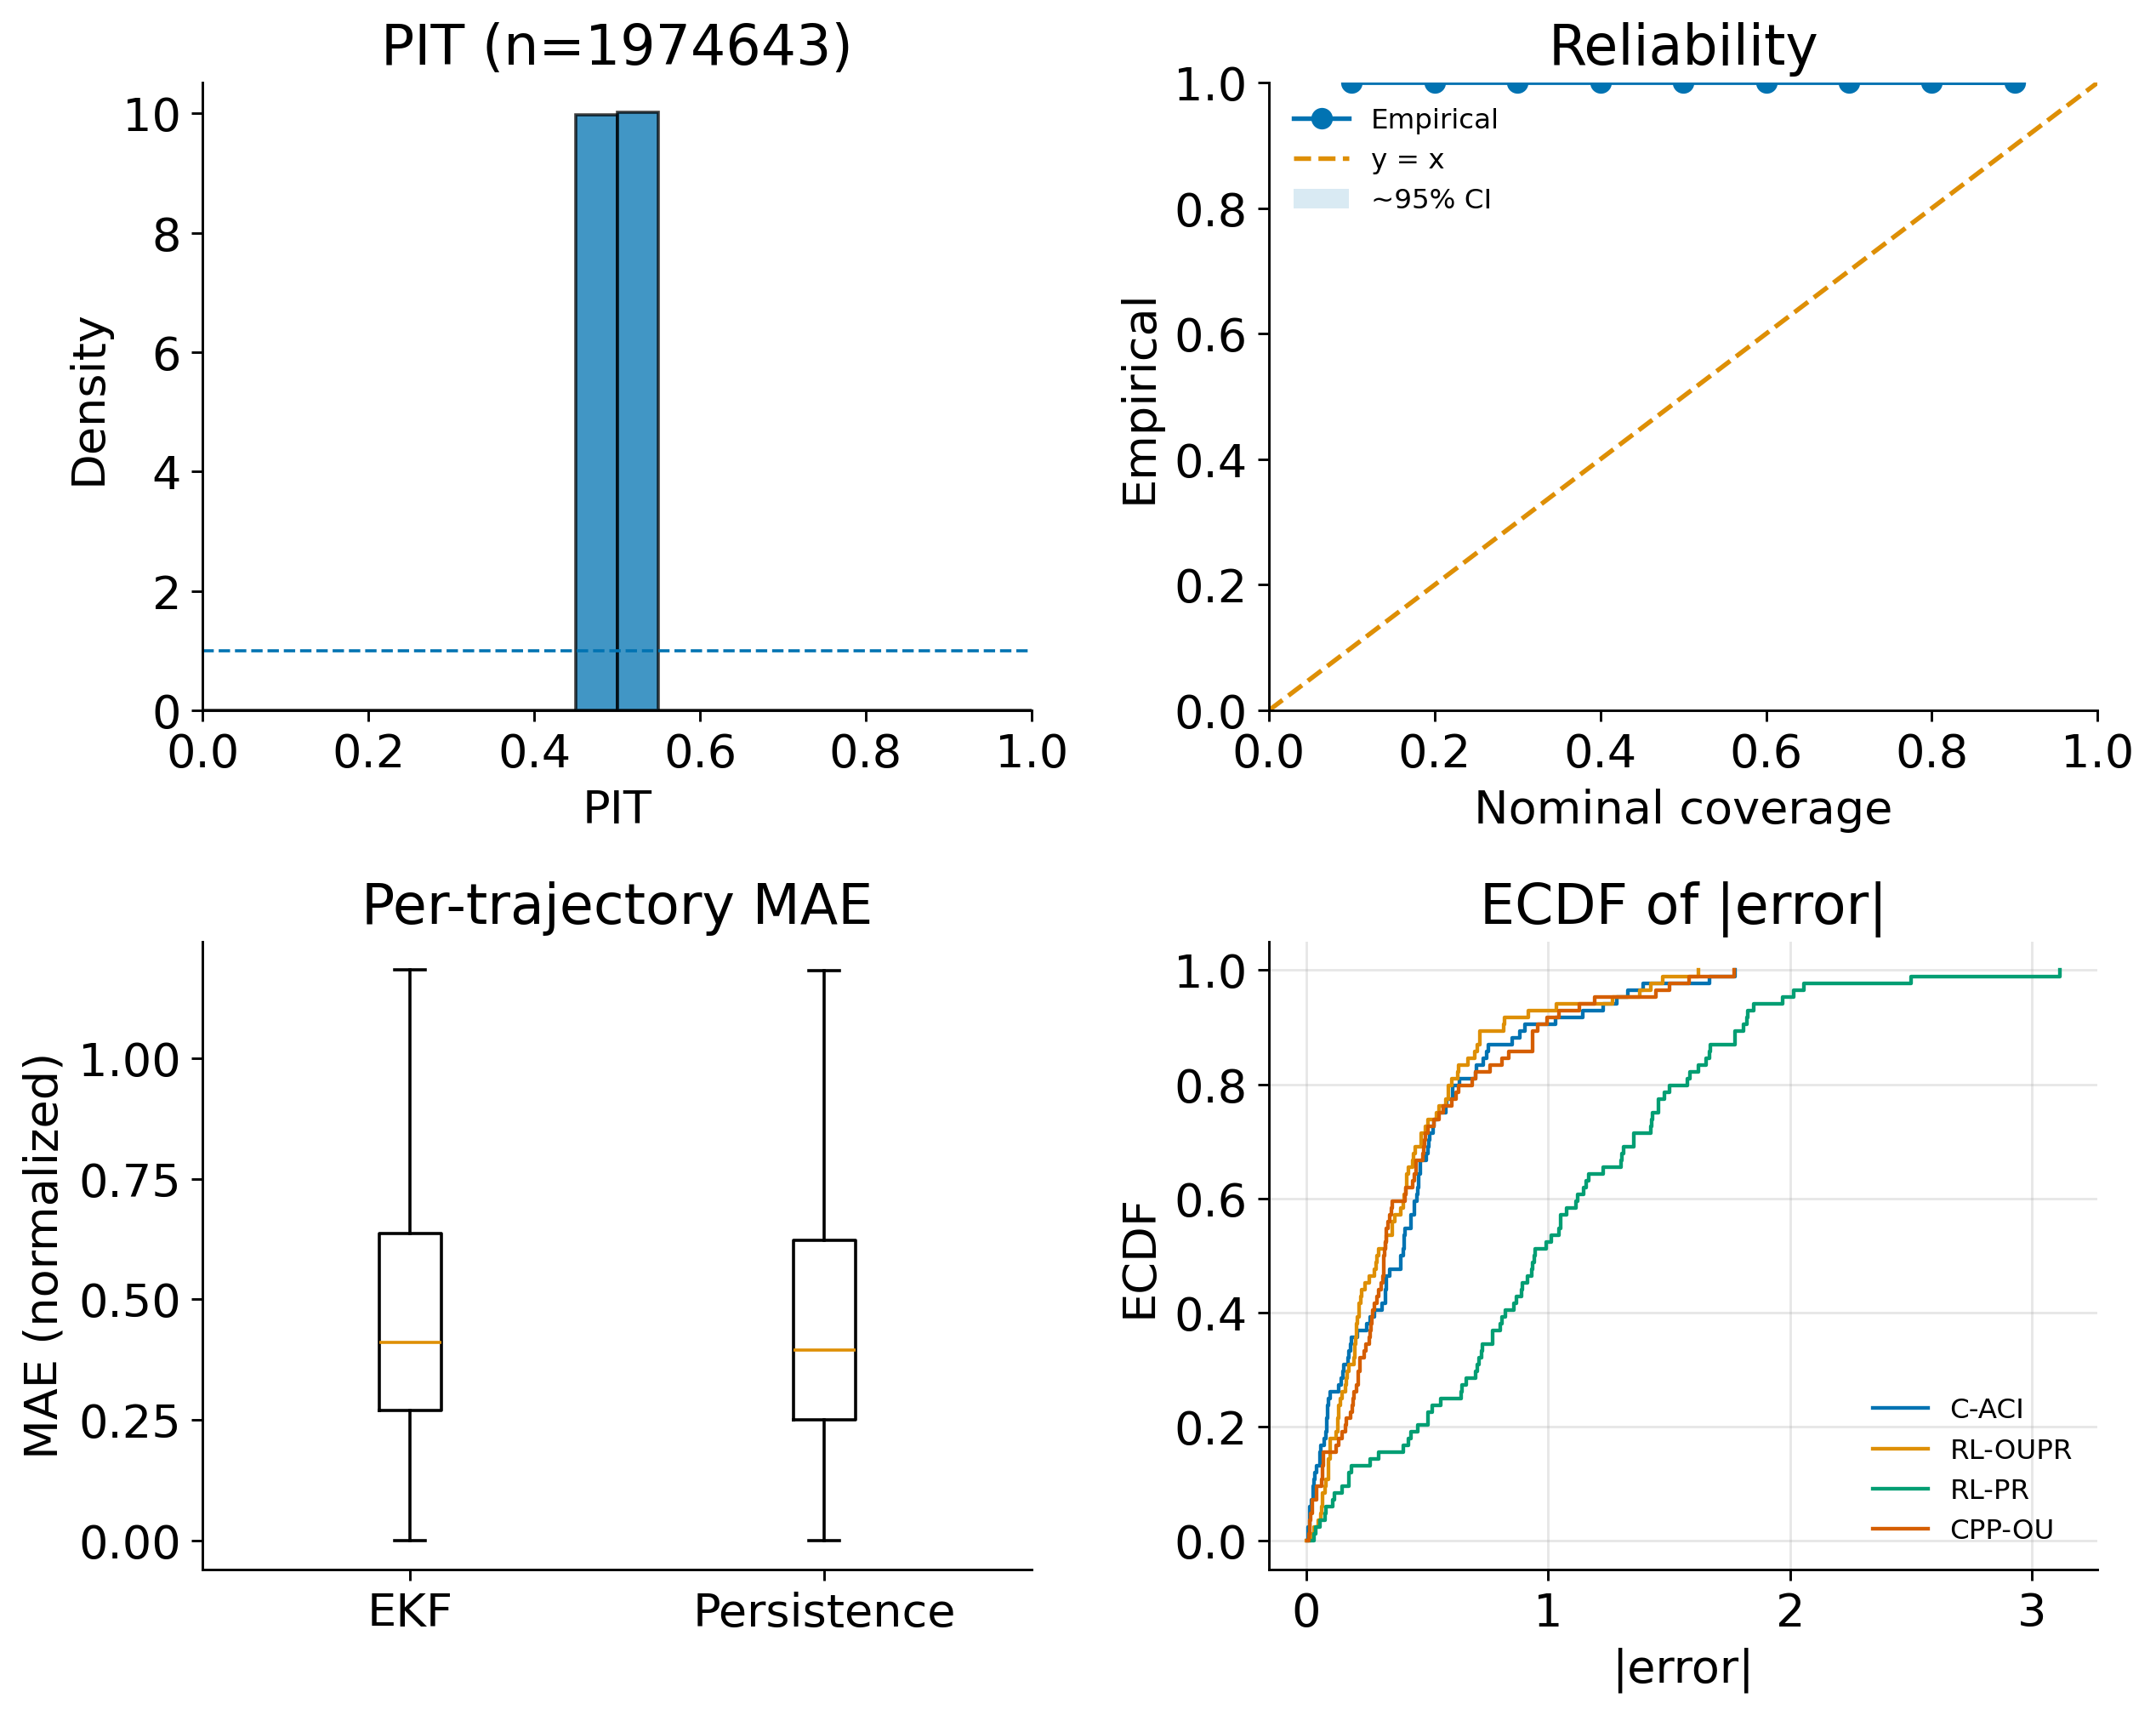

[saved] results/run_20250822_160711/figures/paper_style_panels.png

[done] All figures attempted. Check messages above for any [skip] notes.


In [65]:
# === ROBUST FIGURE SUITE (English labels, no LaTeX, with sanity checks) ===
import os, json, numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# 0) Matplotlib safe defaults (disable TeX, fix unicode minus)
mpl.rcParams.update({
    "text.usetex": False,
    "axes.unicode_minus": False,
    "figure.dpi": 130,
    "savefig.bbox": "tight"
})

FIG_DIR = os.path.join(RUN_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def _clean_1d(a):
    """Return a 1D numpy array with only finite values."""
    a = np.asarray(a).ravel()
    a = a[np.isfinite(a)]
    return a

def _safe_tight():
    try:
        plt.tight_layout()
    except Exception:
        pass

def _save_show(fig_name):
    out = os.path.join(FIG_DIR, fig_name)
    _safe_tight()
    plt.savefig(out, dpi=200)
    plt.show()
    plt.close()
    print(f"[saved] {out}")

# --------------------------------------------------------------------------------------
# 1) Quick diagnostics — see what we actually have
# --------------------------------------------------------------------------------------
print("\n=== PLOT DIAGNOSTICS ===")
if isinstance(hist_collection, dict):
    print("hist_collection keys:", list(hist_collection.keys()))
    for k, v in hist_collection.items():
        vv = np.asarray(v)
        print(f" - {k}: shape={vv.shape}, finite={np.isfinite(vv).sum()}/{vv.size}")
else:
    print("hist_collection is missing or not a dict!")

if "test_df" in globals():
    if isinstance(test_df, pd.DataFrame):
        print("test_df columns:", list(test_df.columns))
        print("test_df shape:", test_df.shape)
    else:
        print("test_df exists but is not a DataFrame!")
else:
    print("test_df not found in globals.")

if "pit_all" in globals():
    pa = _clean_1d(pit_all) if pit_all is not None else np.array([])
    print(f"pit_all length (finite): {len(pa)}")
else:
    print("pit_all not found in globals.")

# --------------------------------------------------------------------------------------
# 2) PIT histogram
# --------------------------------------------------------------------------------------
pa = _clean_1d(pit_all) if "pit_all" in globals() and pit_all is not None else np.array([])
if len(pa) > 0:
    plt.figure(figsize=(6.0,3.8))
    plt.hist(pa, bins=20, range=(0,1), density=True, alpha=0.75, edgecolor="k")
    plt.axhline(1.0, ls="--", lw=1)
    plt.xlim(0,1); plt.ylim(0, None)
    plt.xlabel("PIT")
    plt.ylabel("Density")
    plt.title(f"PIT Histogram (n={len(pa)})")
    txt = f"mean={pa.mean():.3f}\nvar={pa.var():.3f}"
    plt.text(0.02, 0.95, txt, transform=plt.gca().transAxes,
             va="top", ha="left", fontsize=9)
    _save_show("pit_hist.png")
else:
    print("[skip] PIT histogram — no finite PIT values.")

# --------------------------------------------------------------------------------------
# 3) Reliability / central coverage from PIT
# --------------------------------------------------------------------------------------
if len(pa) > 0:
    coverages = np.linspace(0.1, 0.9, 9)
    emp_cov = []
    for c in coverages:
        a, b = c/2.0, 1.0 - c/2.0
        emp_cov.append(np.mean((pa >= a) & (pa <= b)))
    emp_cov = np.array(emp_cov)

    N = len(pa)
    se = np.sqrt(np.clip(emp_cov*(1-emp_cov)/max(N,1), 0, None))
    lo = np.clip(emp_cov - 1.96*se, 0, 1)
    hi = np.clip(emp_cov + 1.96*se, 0, 1)

    plt.figure(figsize=(6.0,3.8))
    plt.plot(coverages, emp_cov, marker="o", label="Empirical")
    plt.plot([0,1], [0,1], ls="--", label="y = x (ideal)")
    plt.fill_between(coverages, lo, hi, alpha=0.15, label="~95% CI")
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel("Nominal coverage")
    plt.ylabel("Empirical coverage")
    plt.title("Reliability (central coverage via PIT)")
    plt.legend(frameon=False)
    _save_show("reliability.png")
else:
    print("[skip] Reliability curve — no PIT.")

# --------------------------------------------------------------------------------------
# 4) Per-trajectory MAE boxplot (normalized space) + persistence if present
# --------------------------------------------------------------------------------------
has_test = ("test_df" in globals()) and isinstance(test_df, pd.DataFrame) and len(test_df)>0
if has_test and "mae" in test_df.columns:
    vals = []
    labels = []
    vals.append(_clean_1d(test_df["mae"].to_numpy()))
    labels.append("EKF")
    if "mae_persist" in test_df.columns:
        vals.append(_clean_1d(test_df["mae_persist"].to_numpy()))
        labels.append("Persistence")

    # Drop any series that turned empty after cleaning
    keep = [i for i, v in enumerate(vals) if len(v) > 0]
    if len(keep) > 0:
        plt.figure(figsize=(5.8,3.8))
        plt.boxplot([vals[i] for i in keep], labels=[labels[i] for i in keep], showfliers=False)
        plt.ylabel("MAE (normalized)")
        ttl_extra = " (EKF vs Persistence)" if len(keep)==2 else ""
        plt.title("Per-trajectory MAE" + ttl_extra)
        _save_show("mae_boxplot.png")
    else:
        print("[skip] MAE box — empty after cleaning.")
else:
    print("[skip] MAE box — test_df missing or 'mae' column not found.")

# --------------------------------------------------------------------------------------
# 5) Time-binned Median |error| per method (normalized)
#    If you have a true time vector t, pass it; else we fall back to index bins.
# --------------------------------------------------------------------------------------
def build_errs_df(hist_collection):
    """Align methods to same min length; drop NaN/Inf; return DataFrame."""
    if not isinstance(hist_collection, dict) or len(hist_collection)==0:
        return None
    # Clean each series
    cleaned = {}
    lengths = []
    for k, v in hist_collection.items():
        vv = _clean_1d(v)
        if len(vv) > 0:
            cleaned[k] = vv
            lengths.append(len(vv))
    if len(cleaned)==0:
        return None
    L = int(np.min(lengths))
    if L == 0:
        return None
    # Crop to common length
    data = {k: cleaned[k][:L] for k in cleaned.keys()}
    df = pd.DataFrame(data, index=pd.RangeIndex(L))
    return df

errs_df = build_errs_df(hist_collection)

if errs_df is None or errs_df.shape[0] == 0:
    print("[skip] Time-binned plots — hist_collection empty after cleaning.")
else:
    # If you have a real time array aligned to errors, provide it here; otherwise use a fake time index.
    # Try to infer t_used from a previous 'index' (if you kept one) else fallback to 0..L-1
    if "index" in globals() and isinstance(index, (pd.Index, np.ndarray, list)) and len(index) >= len(errs_df):
        t_used = np.asarray(index[:len(errs_df)])
        # If index is timestamp-like numeric, good. If not numeric, fall back.
        if not np.issubdtype(t_used.dtype, np.number):
            try:
                t_used = pd.to_numeric(t_used, errors="coerce").to_numpy()
            except Exception:
                t_used = np.arange(len(errs_df))
    else:
        t_used = np.arange(len(errs_df))

    # Fixed-length bins by step count (e.g., 600 steps ~ 10 min if 1Hz)
    # If your sampling is irregular, prefer real time bins; otherwise this is fine.
    steps_per_bin = 600
    groups = (np.arange(len(errs_df)) // max(1, steps_per_bin)).astype(int)
    group_index = pd.Index([f"bin_{g:04d}" for g in groups])

    mdae_by_bin = errs_df.abs().groupby(group_index).median()
    mae_by_bin  = errs_df.abs().groupby(group_index).mean()

    # Print overall normalized MdAE by method (quick table)
    mdae_overall = errs_df.abs().median().sort_values()
    print("\n[overall MdAE | normalized]")
    print(mdae_overall)

    # Plot MdAE per bin
    plt.figure(figsize=(7.8,3.8))
    mdae_by_bin.plot(ax=plt.gca())
    plt.title(f"Median |error| per bin (normalized, {steps_per_bin} steps/bin)")
    plt.xlabel("Bin")
    plt.ylabel("Median |error|")
    plt.grid(alpha=0.3)
    _save_show("mdae_per_bin_normalized.png")

    # Optional: Improvement vs baseline (↑ better)
    if "baseline" in errs_df.columns:
        impr = (mdae_by_bin.subtract(mdae_by_bin["baseline"], axis=0)) * -1.0
        cols = [c for c in impr.columns if c != "baseline"]
        if len(cols) > 0:
            plt.figure(figsize=(7.4,3.8))
            impr[cols].plot(ax=plt.gca())
            plt.axhline(0, lw=1, ls="--", color="k")
            plt.title("Improvement vs Baseline (positive = better)")
            plt.xlabel("Bin")
            plt.ylabel("Δ Median |error|")
            plt.grid(alpha=0.3)
            _save_show("improvement_vs_baseline.png")
        else:
            print("[skip] Improvement plot — only baseline present.")
    else:
        print("[skip] Improvement plot — 'baseline' not in errs_df.")

# --------------------------------------------------------------------------------------
# 6) Error distribution per method (KDE/Hist side-by-side) — normalized space
# --------------------------------------------------------------------------------------
if errs_df is not None and errs_df.shape[0] > 0:
    # Histograms
    plt.figure(figsize=(7.8,4.0))
    for col in errs_df.columns:
        ec = _clean_1d(errs_df[col])
        if len(ec) == 0:
            continue
        plt.hist(ec, bins=40, alpha=0.35, density=True, label=col)
    plt.title("Error distribution (normalized space)")
    plt.xlabel("Error (ŷ − y)")
    plt.ylabel("Density")
    plt.legend(frameon=False)
    _save_show("error_distributions_hist.png")

    # Empirical CDFs (absolute error)
    plt.figure(figsize=(7.8,4.0))
    for col in errs_df.columns:
        ae = np.sort(np.abs(_clean_1d(errs_df[col])))
        if len(ae) == 0:
            continue
        ycdf = np.linspace(0,1,len(ae), endpoint=True)
        plt.step(ae, ycdf, where="post", linewidth=1.2, label=col)
    plt.title("ECDF of |error| (normalized)")
    plt.xlabel("|error|")
    plt.ylabel("ECDF")
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    _save_show("ecdf_abs_error.png")
else:
    print("[skip] Error distributions — no errors to plot.")

# --------------------------------------------------------------------------------------
# 7) Optional: paper-style quick panels
#    (i) PIT histogram, (ii) Reliability, (iii) Per-traj MAE box,
#    (iv) ECDF of |error|  — all in one compact figure for the thesis.
# --------------------------------------------------------------------------------------
def _paper_style_panels():
    cols = 2
    rows = 2
    fig, axes = plt.subplots(rows, cols, figsize=(10,8))
    ax11, ax12 = axes[0]
    ax21, ax22 = axes[1]

    # (i) PIT hist
    if len(pa) > 0:
        ax11.hist(pa, bins=20, range=(0,1), density=True, alpha=0.75, edgecolor="k")
        ax11.axhline(1.0, ls="--", lw=1)
        ax11.set_xlim(0,1); ax11.set_ylim(0,None)
        ax11.set_xlabel("PIT"); ax11.set_ylabel("Density")
        ax11.set_title(f"PIT (n={len(pa)})")
    else:
        ax11.text(0.5, 0.5, "No PIT", ha="center", va="center")
        ax11.set_axis_off()

    # (ii) Reliability
    if len(pa) > 0:
        coverages = np.linspace(0.1, 0.9, 9)
        emp_cov = []
        for c in coverages:
            a, b = c/2.0, 1.0 - c/2.0
            emp_cov.append(np.mean((pa >= a) & (pa <= b)))
        emp_cov = np.array(emp_cov)
        N = len(pa)
        se = np.sqrt(np.clip(emp_cov*(1-emp_cov)/max(N,1), 0, None))
        lo = np.clip(emp_cov - 1.96*se, 0, 1)
        hi = np.clip(emp_cov + 1.96*se, 0, 1)

        ax12.plot(coverages, emp_cov, marker="o", label="Empirical")
        ax12.plot([0,1], [0,1], ls="--", label="y = x")
        ax12.fill_between(coverages, lo, hi, alpha=0.15, label="~95% CI")
        ax12.set_xlim(0,1); ax12.set_ylim(0,1)
        ax12.set_xlabel("Nominal coverage"); ax12.set_ylabel("Empirical")
        ax12.set_title("Reliability")
        ax12.legend(frameon=False, fontsize=9)
    else:
        ax12.text(0.5, 0.5, "No PIT", ha="center", va="center")
        ax12.set_axis_off()

    # (iii) MAE box
    if has_test and "mae" in test_df.columns:
        vals, labels = [], []
        v_ekf = _clean_1d(test_df["mae"].to_numpy())
        if len(v_ekf)>0:
            vals.append(v_ekf); labels.append("EKF")
        if "mae_persist" in test_df.columns:
            v_p = _clean_1d(test_df["mae_persist"].to_numpy())
            if len(v_p)>0:
                vals.append(v_p); labels.append("Persistence")
        if len(vals)>0:
            ax21.boxplot(vals, labels=labels, showfliers=False)
            ax21.set_ylabel("MAE (normalized)")
            ax21.set_title("Per-trajectory MAE")
        else:
            ax21.text(0.5, 0.5, "No MAE values", ha="center", va="center")
            ax21.set_axis_off()
    else:
        ax21.text(0.5, 0.5, "No MAE table", ha="center", va="center")
        ax21.set_axis_off()

    # (iv) ECDF |error|
    if errs_df is not None and errs_df.shape[0]>0:
        for col in errs_df.columns:
            ae = np.sort(np.abs(_clean_1d(errs_df[col])))
            if len(ae)==0: 
                continue
            ycdf = np.linspace(0,1,len(ae), endpoint=True)
            ax22.step(ae, ycdf, where="post", linewidth=1.2, label=col)
        ax22.set_title("ECDF of |error|")
        ax22.set_xlabel("|error|"); ax22.set_ylabel("ECDF")
        ax22.grid(alpha=0.3); ax22.legend(frameon=False, fontsize=9)
    else:
        ax22.text(0.5, 0.5, "No errors", ha="center", va="center")
        ax22.set_axis_off()

    _safe_tight()
    out = os.path.join(FIG_DIR, "paper_style_panels.png")
    plt.savefig(out, dpi=220)
    plt.show(); plt.close()
    print(f"[saved] {out}")

# Build the compact paper-style figure too
_paper_style_panels()

print("\n[done] All figures attempted. Check messages above for any [skip] notes.")
